# VahaanBandhu — Classical and Quantum-Enhanced Route Optimization

**Research notebook**

This notebook defines the VahaanBandhu routing problem, builds classical baselines,
derives a quantum formulation, validates it classically, runs it on a simulator, and
compares everything on **identical instances against identical cost matrices**.

## The research question, stated precisely

> Can quantum or hybrid quantum-classical optimization improve candidate-route selection
> or constrained circular-logistics optimization, *after* the classical road network has
> already reduced the search space?

Note what this question is not. It is not "is quantum faster". Every runtime comparison
below decomposes into classical preprocessing, solver time, quantum execution and
postprocessing, because a simulator beating an inefficient Python loop demonstrates
nothing about quantum computing.

## The architectural rule this notebook exists to justify

Quantum hardware is **never** called in the live request path. Queue latency alone makes
that indefensible for a farmer requesting a truck. Hardware is an offline research and
benchmarking instrument; its *outputs* — validated parameters, benchmark references,
route priors — are what production may consume.

In [1]:
import sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=DeprecationWarning)
# Walk up to the repository root (the directory containing the `vb` package)
# rather than assuming a fixed depth, so the notebook keeps working wherever it
# is opened from.
_root = Path.cwd()
while not (_root / "vb").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
print("ready")

ready


## Part 1 — Problem definition

VahaanBandhu's routing problem is broader than "shortest path from A to B". The node
types and their relationships:

| Node | Role |
|---|---|
| **farmer node** | crop pickup point (privacy-safe, never a residence) |
| **mandi** | agricultural market, the forward destination |
| **shop** | rural building-material dealer, the return destination |
| **depot** | truck home base; start and end of a circular tour |

The sequences that matter:

```
truck -> farm -> mandi                          (forward only)
truck -> farm(s) -> mandi                       (milk-run collection)
truck -> farm -> mandi -> supplier -> shop -> depot   (circular)
```

The last one is the product thesis. A truck that carries grain to a mandi and drives
home empty wastes half its distance. If a building-material load is waiting near that
mandi and heading back along the same corridor, the same kilometres earn twice.

**The objective is therefore multi-dimensional**, and the shortest route is frequently
not the best one:

```
minimize   distance + time + fuel + toll + risk + empty_km_penalty
                    - circular_logistics_benefit
```

In [2]:
from routing.objective import DEFAULT_WEIGHTS
from vb.generate.instances import DEFAULT_OBJECTIVE_WEIGHTS

print("Objective weights (stored in data and carried on every instance):")
print(json.dumps(DEFAULT_WEIGHTS, indent=2))
assert DEFAULT_WEIGHTS == DEFAULT_OBJECTIVE_WEIGHTS, "engine and dataset weights diverged"
print("\nEngine and dataset weight definitions agree.")
print("Note circular_bonus is NEGATIVE: a return load improves the objective.")

Objective weights (stored in data and carried on every instance):
{
  "distance_km": 1.0,
  "time_min": 0.35,
  "fuel_inr": 0.01,
  "toll_inr": 0.01,
  "risk": 12.0,
  "empty_km": 0.85,
  "circular_bonus": -1.1
}

Engine and dataset weight definitions agree.
Note circular_bonus is NEGATIVE: a return load improves the objective.


## Part 2 — Data loading

In [3]:
from vb import config as C

locations = pd.read_csv(C.MASTER/"locations_master.csv")
mandis    = pd.read_csv(C.MASTER/"mandis.csv")
shops     = pd.read_csv(C.SYNTHETIC/"shops.csv")
farmers   = pd.read_csv(C.SYNTHETIC/"farmer_nodes.csv")
trucks    = pd.read_csv(C.SYNTHETIC/"trucks.csv")
requests  = pd.read_csv(C.SYNTHETIC/"transport_requests.csv", low_memory=False)
edges     = pd.read_csv(C.SYNTHETIC/"route_edges.csv")
instances = pd.read_csv(C.SYNTHETIC/"route_instances.csv")

for name, df in [("locations",locations),("mandis",mandis),("shops",shops),
                 ("farmer_nodes",farmers),("trucks",trucks),("requests",requests),
                 ("route_edges",edges),("route_instances",instances)]:
    print(f"  {name:16s} {len(df):>8,} rows")
print(f"\nscenarios in graph: {sorted(edges.scenario_id.unique())}")

  locations           3,442 rows
  mandis                 50 rows
  shops                 900 rows
  farmer_nodes        1,400 rows
  trucks                600 rows
  requests           18,000 rows
  route_edges       375,968 rows
  route_instances     2,000 rows

scenarios in graph: ['SCN_BASELINE', 'SCN_EVENING_PEAK', 'SCN_HARVEST_PEAK', 'SCN_MIDDAY', 'SCN_MONSOON_RAIN', 'SCN_MORNING_PEAK', 'SCN_NIGHT', 'SCN_WEEKEND']


## Part 3 — Geospatial visualization

road graph: 3,442 nodes, 46,996 directed edges


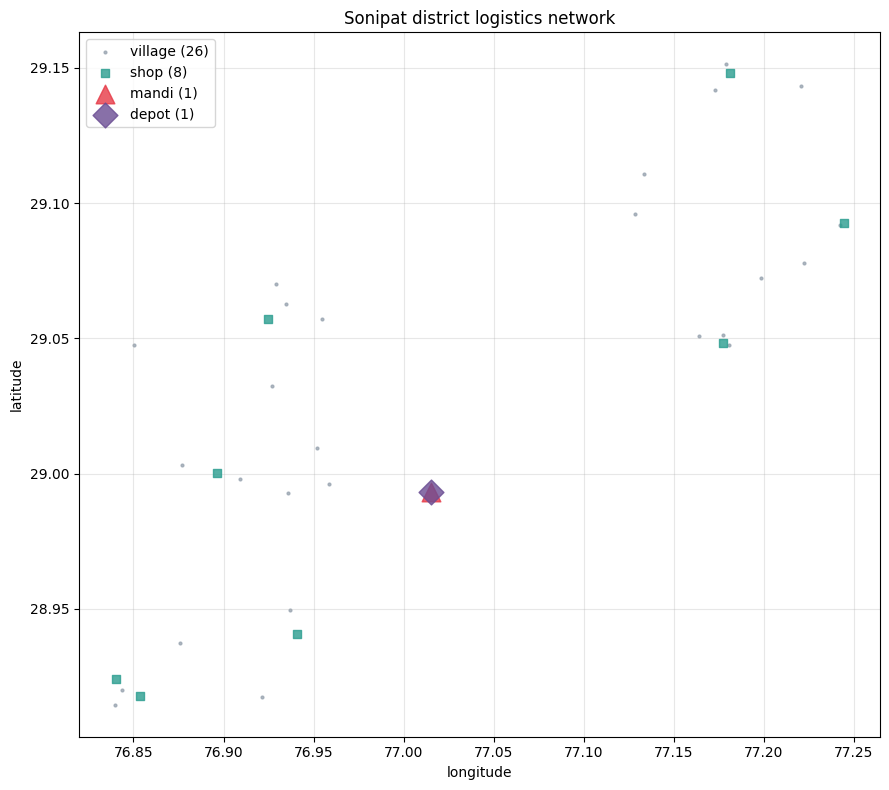

In [4]:
from routing.providers.offline import OfflineGraphProvider
provider = OfflineGraphProvider(edges, locations, scenario_id="SCN_BASELINE")
print(f"road graph: {provider.G.number_of_nodes():,} nodes, {provider.G.number_of_edges():,} directed edges")

# Focus on one district so the picture is readable.
DISTRICT = "Sonipat"
loc_d = locations[locations.district == DISTRICT]
fig, ax = plt.subplots(figsize=(9, 8))
style = {"village":("#9aa5b1",4,"o"), "shop":("#2a9d8f",26,"s"),
         "mandi":("#e63946",180,"^"), "depot":("#6a4c93",160,"D")}
for t,(c,s,m) in style.items():
    g = loc_d[loc_d.location_type == t]
    ax.scatter(g.longitude, g.latitude, c=c, s=s, marker=m, label=f"{t} ({len(g)})",
               alpha=0.8, zorder=3 if t!="village" else 1)
ax.set(title=f"{DISTRICT} district logistics network", xlabel="longitude", ylabel="latitude")
ax.legend(); plt.tight_layout(); plt.show()

Circular chain candidate:
  depot    LOC_2E9E391564C2  Sonipat Transport Depot                (28.9931,77.0151)
  farm     LOC_A02EDB30449A  Jhinjhana Nagar                        (29.0777,77.2222)
  mandi    LOC_2D9C52DA14E3  Sonipat Grain Market                   (28.9931,77.0151)
  shop     LOC_F9EDEB0869A0  Gupta Building Materials               (29.0572,76.9249)


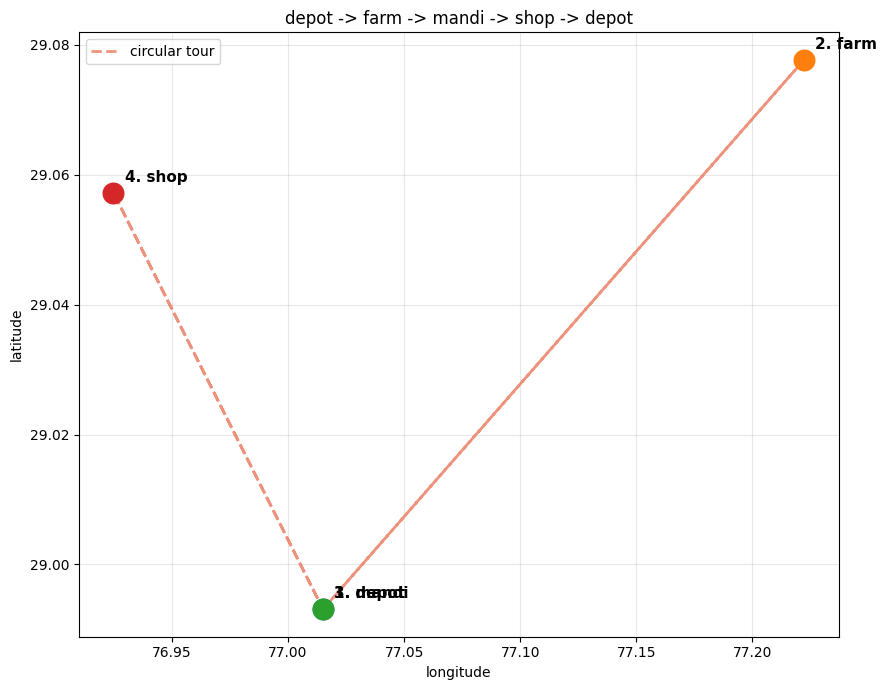

In [5]:
# A concrete truck -> farm -> mandi -> shop chain, drawn on the road graph.
from vb.geo import haversine_km
import networkx as nx

depot_row = locations[(locations.district==DISTRICT)&(locations.location_type=="depot")].iloc[0]
mandi_row = locations[(locations.district==DISTRICT)&(locations.location_type=="mandi")].iloc[0] \
            if ((locations.district==DISTRICT)&(locations.location_type=="mandi")).any() \
            else locations[locations.location_type=="mandi"].iloc[0]
village_row = locations[(locations.district==DISTRICT)&(locations.location_type=="village")].iloc[0]
shop_row = locations[(locations.district==DISTRICT)&(locations.location_type=="shop")].iloc[0]

chain = [("depot",depot_row),("farm",village_row),("mandi",mandi_row),("shop",shop_row)]
print("Circular chain candidate:")
for label,row in chain:
    print(f"  {label:8s} {row.location_id}  {row.name_en[:38]:38s} ({row.latitude:.4f},{row.longitude:.4f})")

fig, ax = plt.subplots(figsize=(9,7))
for i,(label,row) in enumerate(chain):
    ax.scatter(row.longitude,row.latitude,s=220,zorder=5)
    ax.annotate(f"{i+1}. {label}", (row.longitude,row.latitude),
                xytext=(8,8), textcoords="offset points", fontsize=11, weight="bold")
seq = chain + [chain[0]]
ax.plot([r.longitude for _,r in seq], [r.latitude for _,r in seq],
        "--", c="#e76f51", lw=2, alpha=0.75, label="circular tour")
ax.set(title="depot -> farm -> mandi -> shop -> depot", xlabel="longitude", ylabel="latitude")
ax.legend(); plt.tight_layout(); plt.show()

## Part 4 — Routing providers and candidate retrieval

The optimization layer never touches vendor JSON. It consumes `RouteCandidate` objects
from a `RoutingProvider`, which means TomTom can be swapped, mocked or unavailable
without any solver changing.

**On caching and licensing:** TomTom responses go into a short-TTL *operational* cache,
never into `Data/`. Their terms on storing and redistributing responses as derived
training data are unverified, which is why `route_edges` ships with offline
detour-model costs instead.

In [6]:
from routing.providers.tomtom import TomTomRoutingProvider
tomtom = TomTomRoutingProvider()
print(f"TomTom configured: {bool(tomtom._keys)} ({len(tomtom._keys)} keys)")
print(f"TomTom available : {tomtom.available}")
print("\nThis notebook runs entirely on the OFFLINE provider so it is reproducible")
print("without network access and consumes no API quota.")

TomTom configured: False (0 keys)
TomTom available : False

This notebook runs entirely on the OFFLINE provider so it is reproducible
without network access and consumes no API quota.


In [7]:
from routing.models import LatLon
from routing.classical.shortest_path import k_shortest_paths

origin_id, dest_id = village_row.location_id, mandi_row.location_id
cands = provider.get_alternative_routes(None, None, max_alternatives=4,
                                        origin_id=origin_id, destination_id=dest_id)
print(f"{len(cands)} candidate routes from {village_row.name_en} to {mandi_row.name_en}\n")
display(pd.DataFrame([c.to_dict() for c in cands])[
    ["route_id","distance_km","travel_time_min","traffic_delay_min",
     "toll_cost_inr","estimated_fuel_cost_inr","road_risk_score"]])

4 candidate routes from Jhinjhana Nagar to Sonipat Grain Market



,route_id,distance_km,travel_time_min,traffic_delay_min,toll_cost_inr,estimated_fuel_cost_inr,road_risk_score
0,OFF_LOC_A02E_LOC_2D9C_0,30.217,39.42,0.00,10.64,556.00,0.3645
1,OFF_LOC_A02E_LOC_2D9C_1,27.844,36.32,1.27,14.21,512.33,0.3910
2,OFF_LOC_A02E_LOC_2D9C_2,28.970,37.78,0.39,12.19,533.05,0.4415
3,OFF_LOC_A02E_LOC_2D9C_3,30.715,40.07,0.00,10.65,565.15,0.3847


## Part 5 — Candidate features and Experiment A/B

### EXPERIMENT A — simple A → B routing

In [8]:
from routing.classical.shortest_path import dijkstra, astar
coords = {r.location_id:(r.latitude,r.longitude) for r in locations.itertuples()}

dj = dijkstra(provider.G, origin_id, dest_id, weight="distance_km")
ast = astar(provider.G, origin_id, dest_id, coords, weight="distance_km")
print("EXPERIMENT A - shortest path A to B")
print(f"  Dijkstra: {dj.distance_km:8.2f} km  {len(dj.path)} hops  {dj.runtime_ms:.2f} ms")
print(f"  A*      : {ast.distance_km:8.2f} km  {len(ast.path)} hops  {ast.runtime_ms:.2f} ms")
assert abs(dj.cost-ast.cost)<1e-6, "A* heuristic is not admissible"
print("\n  Both find the same optimum -- the haversine heuristic is admissible,")
print("  because road distance is always at least the great-circle distance.")

EXPERIMENT A - shortest path A to B
  Dijkstra:    27.84 km  2 hops  3.08 ms
  A*      :    27.84 km  2 hops  0.67 ms

  Both find the same optimum -- the haversine heuristic is admissible,
  because road distance is always at least the great-circle distance.


### EXPERIMENT B — traffic-aware candidate selection

In [9]:
from routing.objective import select_best, explain_selection, score_candidate

best, breakdown, ranking = select_best(cands)
print("EXPERIMENT B - multi-objective selection among candidates\n")
rows=[]
for c,s in ranking:
    rows.append({"route_id":c.route_id,"dist_km":round(c.distance_km,1),
                 "eta_min":round(c.travel_time_min+c.traffic_delay_min,1),
                 "traffic_delay":round(c.traffic_delay_min,1),
                 "risk":round(c.road_risk_score,3),
                 "score":round(s.total,2)})
display(pd.DataFrame(rows))

shortest = min(cands, key=lambda c:c.distance_km)
print(f"\nshortest route : {shortest.route_id} ({shortest.distance_km:.1f} km)")
print(f"selected route : {best.route_id} ({best.distance_km:.1f} km)")
print("SAME" if shortest.route_id==best.route_id else "DIFFERENT -- distance alone was not decisive")
print("\nExplanation returned to the UI:")
print(json.dumps(explain_selection(best,breakdown,ranking), indent=2))

EXPERIMENT B - multi-objective selection among candidates



,route_id,dist_km,eta_min,traffic_delay,risk,score
0,OFF_LOC_A02E_LOC_2D9C_1,27.8,37.6,1.3,0.391,50.96
1,OFF_LOC_A02E_LOC_2D9C_2,29.0,38.2,0.4,0.442,53.08
2,OFF_LOC_A02E_LOC_2D9C_0,30.2,39.4,0.0,0.364,54.05
3,OFF_LOC_A02E_LOC_2D9C_3,30.7,40.1,0.0,0.385,55.11



shortest route : OFF_LOC_A02E_LOC_2D9C_1 (27.8 km)
selected route : OFF_LOC_A02E_LOC_2D9C_1 (27.8 km)
SAME

Explanation returned to the UI:
{
  "selected_route_id": "OFF_LOC_A02E_LOC_2D9C_1",
  "distance_km": 27.84,
  "eta_min": 37.6,
  "traffic_delay_min": 1.3,
  "estimated_fuel_cost_inr": 512.33,
  "estimated_toll_inr": 14.21,
  "total_estimated_cost_inr": 526.54,
  "empty_km": 0.0,
  "loaded_km": 27.84,
  "circular_logistics_score": 0.0,
  "selection_score": 50.958,
  "margin_over_runner_up": 2.122,
  "margin_is_decisive": true,
  "primary_selection_reasons": [
    "distance_km penalised (+27.8)",
    "time_min penalised (+13.2)",
    "fuel_inr penalised (+5.1)"
  ],
  "n_candidates_considered": 4
}


Note the `margin_is_decisive` field. When the top two routes score within 2% of each
other the engine reports a near-tie rather than presenting a confident winner — showing
false certainty to a driver is worse than showing none.

## Part 6 — Experiment C: truck → farm → mandi

In [10]:
from routing.engine import RouteEngine
from routing.circular import evaluate_direct_trip, evaluate_circular_trip, find_return_loads

engine = RouteEngine(primary_provider=provider, fallback_provider=None)
truck = trucks[trucks.district==DISTRICT].sort_values("capacity_kg",ascending=False).iloc[0]
print(f"Truck {truck.truck_id}: {truck.vehicle_class}, {truck.capacity_kg:,.0f} kg, {truck.avg_kmpl} kmpl")

LOAD_KG = 2000.0
decision = engine.select_route(None, None, origin_id=origin_id, destination_id=dest_id,
                               load_kg=LOAD_KG, vehicle_capacity_kg=truck.capacity_kg)
print(f"\nEXPERIMENT C - farm to mandi, {LOAD_KG:,.0f} kg")
print(f"  provider used : {decision.provider_used}")
print(f"  selected      : {decision.explanation['selected_route_id']}")
print(f"  distance      : {decision.explanation['distance_km']} km")
print(f"  ETA           : {decision.explanation['eta_min']} min")
print(f"  est. cost     : Rs {decision.explanation['total_estimated_cost_inr']}")
print(f"  candidates    : {decision.reduction_stats}")
print(f"  engine runtime: {decision.runtime_ms:.1f} ms")
for w in decision.warnings: print(f"  WARNING: {w}")

Truck TRK_72CA4D066FFF: 2axle, 10,560 kg, 5.99 kmpl

EXPERIMENT C - farm to mandi, 2,000 kg
  provider used : offline_graph
  selected      : OFF_LOC_A02E_LOC_2D9C_1
  distance      : 27.84 km
  ETA           : 37.6 min
  est. cost     : Rs 526.54
  candidates    : {'n_input': 4, 'n_after_pareto': 3, 'n_output': 3, 'n_dominated_removed': 1, 'truncated_by_budget': False, 'truncation_may_discard_optimum': False}
  engine runtime: 7.8 ms


## Part 7 — Experiment D: circular logistics

The comparison that defines the product: the same forward trip, with and without a
return load. A return load only counts if the detour is small relative to the empty
distance it replaces — a shop 80 km off the homeward path is a second job, not a
return load, and the scorer refuses to pretend otherwise.

In [11]:
village_ll = (village_row.latitude, village_row.longitude)
mandi_ll   = (mandi_row.latitude, mandi_row.longitude)
depot_ll   = (depot_row.latitude, depot_row.longitude)
shop_ll    = (shop_row.latitude, shop_row.longitude)
supplier_ll= (mandi_row.latitude+0.02, mandi_row.longitude+0.02)

direct = evaluate_direct_trip(village_ll, mandi_ll, depot_ll,
                              truck.avg_kmpl, truck.capacity_kg, LOAD_KG)
circular = evaluate_circular_trip(village_ll, mandi_ll, supplier_ll, shop_ll, depot_ll,
                                  truck.avg_kmpl, truck.capacity_kg, LOAD_KG, 3000.0)

comp = pd.DataFrame({"without return load":direct.to_dict(),
                     "with return load":circular.to_dict()})
display(comp.loc[["forward_loaded_km","return_loaded_km","empty_km","total_km",
                  "detour_km","truck_utilization","fuel_litres","fuel_cost_inr",
                  "co2_proxy_kg","avoided_empty_km","circular_score","worthwhile"]])
print(f"\nreason: {circular.reason}")
print(f"\nEmpty running: {direct.empty_km:.1f} km -> {circular.empty_km:.1f} km")
print(f"Truck utilization: {direct.truck_utilization:.1%} -> {circular.truck_utilization:.1%}")

,without return load,with return load
forward_loaded_km,30.01,30.01
return_loaded_km,0.0,15.91
empty_km,0.0,19.25
total_km,30.01,65.17
detour_km,0.0,35.17
truck_utilization,1.0,0.7046
fuel_litres,5.01,10.88
fuel_cost_inr,460.87,1000.98
co2_proxy_kg,13.43,29.16
avoided_empty_km,0.0,0.0



reason: detour 35.2 km is inf% of the 0.0 km empty leg it replaces -- above the 45% threshold

Empty running: 0.0 km -> 19.2 km
Truck utilization: 100.0% -> 70.5%


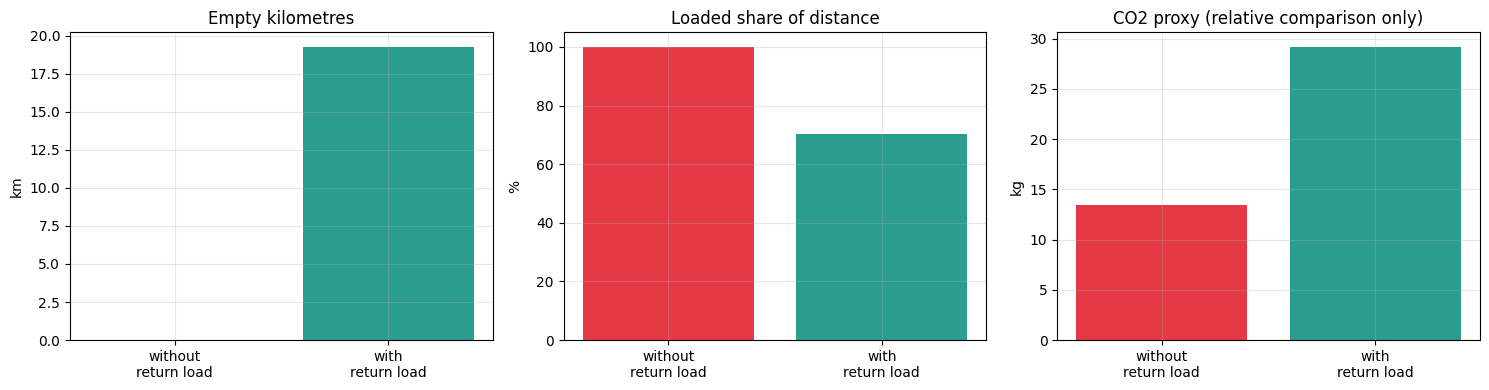

The CO2 figure is a fuel-derived proxy for comparing routes, not a certified estimate.


In [12]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
labels=["without\nreturn load","with\nreturn load"]
axes[0].bar(labels,[direct.empty_km,circular.empty_km],color=["#e63946","#2a9d8f"])
axes[0].set(title="Empty kilometres",ylabel="km")
axes[1].bar(labels,[direct.truck_utilization*100,circular.truck_utilization*100],
            color=["#e63946","#2a9d8f"])
axes[1].set(title="Loaded share of distance",ylabel="%")
axes[2].bar(labels,[direct.co2_proxy_kg,circular.co2_proxy_kg],color=["#e63946","#2a9d8f"])
axes[2].set(title="CO2 proxy (relative comparison only)",ylabel="kg")
plt.tight_layout(); plt.show()
print("The CO2 figure is a fuel-derived proxy for comparing routes, not a certified estimate.")

## Part 8 — Experiment E: operations research baselines

Strong classical baselines come *before* any quantum claim. Where the instance is small
enough, an exact solver provides ground truth, so later results can be reported as a
genuine optimality gap rather than "close to a heuristic".

In [13]:
from routing.instances import list_instances, load_instance
from routing.classical.vrp import solve_vrp

vrp_inst = list_instances(problem_type="CVRP", limit=1)
if len(vrp_inst)==0:
    vrp_inst = list_instances(limit=1)
iid = vrp_inst.iloc[0].instance_id
inst = load_instance(iid)
print(f"instance {iid}")
print(f"  problem     : {inst.problem_type}")
print(f"  nodes       : {inst.n_nodes} ({inst.n_customers} customers + depot)")
print(f"  vehicles    : {len(inst.vehicle_capacities)}")
print(f"  demand      : {inst.demands.sum():,.0f} kg")
print(f"  capacity    : {sum(inst.vehicle_capacities):,.0f} kg")
print(f"  cost snapshot: {inst.cost_snapshot_id}")

sol = solve_vrp(inst, time_limit_s=8, seed=42)
print(f"\nOR-Tools: feasible={sol.feasible}  distance={sol.total_distance_km:.2f} km")
print(f"  routes={len(sol.ordered_stops)}  empty={sol.empty_distance_km:.2f} km")
print(f"  objective={sol.objective_value:.2f}  solver={sol.solver_runtime_ms:.0f} ms")
print(f"  cost_snapshot_id={sol.cost_snapshot_id}")

instance INS_0F9F0C4ACF56
  problem     : CVRP
  nodes       : 5 (4 customers + depot)
  vehicles    : 1
  demand      : 3,630 kg
  capacity    : 17,490 kg
  cost snapshot: CST_48011250D4FB



OR-Tools: feasible=True  distance=96.14 km
  routes=1  empty=14.24 km
  objective=169.91  solver=8001 ms
  cost_snapshot_id=CST_48011250D4FB


In [14]:
from routing.classical.heuristics import (brute_force_tsp, nearest_neighbour,
                                          two_opt, simulated_annealing)
small = list_instances(quantum_ready=True, limit=1).iloc[0].instance_id
si = load_instance(small)
D = si.distance_matrix
print(f"EXPERIMENT E - classical solvers on {small} ({si.n_nodes} nodes)\n")
exact = brute_force_tsp(D)
nn = nearest_neighbour(D); opt = two_opt(D, nn.tour); sa = simulated_annealing(D, seed=1)
res = pd.DataFrame([
    {"algorithm":r.algorithm,"cost_km":round(r.cost,3),"runtime_ms":round(r.runtime_ms,3),
     "gap_vs_optimum":round((r.cost-exact.cost)/exact.cost,5)}
    for r in [exact,nn,opt,sa]])
display(res)
print("\nThe exact row is ground truth. Every gap below is measured against it,")
print("not against another heuristic.")

EXPERIMENT E - classical solvers on INS_A9CA499BC8FF (4 nodes)



,algorithm,cost_km,runtime_ms,gap_vs_optimum
0,brute_force_exact,154.831,0.055,0.00000
1,nearest_neighbour,156.044,0.026,0.00783
2,two_opt,154.831,0.055,0.00000
3,simulated_annealing,154.831,1245.243,0.00000



The exact row is ground truth. Every gap below is measured against it,
not against another heuristic.


## Part 9 — Quantum problem formulation

### Deriving the formulation before writing any Qiskit

**Permutation TSP encoding.** Binary variable $x_{i,t}=1$ iff node $i$ is visited at
position $t$:

$$
\min \sum_{t}\sum_{i \ne j} D_{ij}\, x_{i,t}\, x_{j,t+1}
\;+\; A\sum_i\Big(\sum_t x_{i,t}-1\Big)^2
\;+\; A\sum_t\Big(\sum_i x_{i,t}-1\Big)^2
$$

This needs $n^2$ binary variables. **That is the problem**: 4 nodes is 16 qubits,
5 is 25, 7 is 49. A statevector simulator holds $2^{22}$ amplitudes comfortably and
$2^{49}$ never. This is a measured limit, not a tuning issue.

**Edge-selection encoding** (following Innan et al., *QUAV*, arXiv 2508.21361, which
assigns one qubit per path segment). One binary variable per candidate edge:

$$
\min \sum_{e} c_e\, y_e \;+\; A\sum_{v\in V}\Big(\sum_{e\in \delta^+(v)} y_e - \sum_{e\in \delta^-(v)} y_e - b_v\Big)^2
$$

with $b_v = +1$ at the source, $-1$ at the sink, $0$ elsewhere. This scales with
**edges**, not nodes squared — a 20-edge corridor problem is 20 qubits regardless of
how large the underlying road network is.

### A necessary critique of the source paper

QUAV's cost Hamiltonian is $H_C=\sum_i C(e_i) Z_i$ — **purely linear**. A linear
Hamiltonian is separable: each qubit's optimal value can be read off independently, no
entanglement is required, and QAOA offers nothing over inspection.

Our formulation therefore adds the squared flow-conservation terms, which produce
genuine $Z_iZ_j$ couplings. Those couplings are what make running QAOA a meaningful
thing to do here rather than a decorative one. We verify below that the circuit
actually contains entangling gates.

### Penalty weights

Penalties are derived, not guessed: set strictly above the largest achievable cost
saving, so violating a constraint can never pay for itself. We test this property
exhaustively rather than asserting it.

## Part 10 — QUBO construction

In [15]:
from routing.quantum.qubo import (build_tsp_qubo, build_edge_selection_qubo,
                                  brute_force_qubo, QUBO_VERSION)
from routing.quantum.decoder import decode

# A small, hand-checkable diamond graph: 0->{1,2}->3 plus an expensive direct link.
demo_edges = [(0,1),(1,3),(0,2),(2,3),(0,3)]
demo_costs = np.array([2.0,2.0,1.0,1.5,9.0])
q_edge = build_edge_selection_qubo(demo_edges, demo_costs, source=0, sink=3, n_nodes=4)
print("Edge-selection QUBO:"); print(json.dumps(q_edge.summary(), indent=2))
print(f"\nQ matrix ({q_edge.n_vars}x{q_edge.n_vars}):"); print(np.round(q_edge.Q,2))

Edge-selection QUBO:
{
  "qubo_version": "qubo_v1",
  "encoding": "edge_selection_v1",
  "n_vars": 5,
  "n_quadratic_terms": 8,
  "penalty": 25.5,
  "max_abs_coefficient": 51.0,
  "constant_offset": 51.0,
  "n_edges": 5,
  "n_nodes": 4,
  "source": 0,
  "sink": 3,
  "problem": "constrained_path_selection"
}

Q matrix (5x5):
[[  2.  -51.   51.    0.   51. ]
 [  0.    2.    0.   51.   51. ]
 [  0.    0.    1.  -51.   51. ]
 [  0.    0.    0.    1.5  51. ]
 [  0.    0.    0.    0.  -42. ]]


In [16]:
q_tsp = build_tsp_qubo(D[:4,:4])
print("Encoding cost comparison on the same 4-node problem:")
print(f"  permutation encoding : {q_tsp.n_vars} qubits")
print(f"  edge-selection (5 edges): {q_edge.n_vars} qubits")
print("\nScaling of the permutation encoding:")
for n in range(3,9):
    print(f"  {n} nodes -> {n*n:3d} qubits -> statevector needs 2^{n*n} = {2**(n*n):.3g} amplitudes")
print("\nThis is why QUANTUM_NODE_CEILING is 3 customers, and why the edge")
print("encoding is the one the hybrid pipeline actually uses.")

Encoding cost comparison on the same 4-node problem:
  permutation encoding : 16 qubits
  edge-selection (5 edges): 5 qubits

Scaling of the permutation encoding:
  3 nodes ->   9 qubits -> statevector needs 2^9 = 512 amplitudes
  4 nodes ->  16 qubits -> statevector needs 2^16 = 6.55e+04 amplitudes
  5 nodes ->  25 qubits -> statevector needs 2^25 = 3.36e+07 amplitudes
  6 nodes ->  36 qubits -> statevector needs 2^36 = 6.87e+10 amplitudes
  7 nodes ->  49 qubits -> statevector needs 2^49 = 5.63e+14 amplitudes
  8 nodes ->  64 qubits -> statevector needs 2^64 = 1.84e+19 amplitudes

This is why QUANTUM_NODE_CEILING is 3 customers, and why the edge
encoding is the one the hybrid pipeline actually uses.


## Part 11 — Experiment F: classical QUBO validation (mandatory)

**This step is not optional.** A QUBO that does not encode the routing problem can
still produce a beautifully converging QAOA run — of the wrong problem. Before any
quantum execution we prove three properties by exhaustive enumeration.

In [17]:
import itertools
print("EXPERIMENT F - QUBO validation\n")

x_opt, e_opt = brute_force_qubo(q_edge)
dec = decode(x_opt, q_edge)
print(f"1. Optimum decodes to a valid route")
print(f"   selection : {x_opt.astype(int)}")
print(f"   path      : {dec.tour}   feasible={dec.feasible}")
print(f"   energy    : {e_opt:.3f}")
print(f"   true cheapest path is 0->2->3 costing 1.0 + 1.5 = 2.5")
assert dec.feasible and dec.tour==[0,2,3] and abs(e_opt-2.5)<1e-9

feas, infeas = [], []
for bits in itertools.product([0,1], repeat=q_edge.n_vars):
    x=np.array(bits,dtype=float)
    (feas if decode(x,q_edge).feasible else infeas).append(q_edge.energy(x))
print(f"\n2. Penalty separation (the penalty-method requirement)")
print(f"   worst feasible energy  : {max(feas):.3f}")
print(f"   best infeasible energy : {min(infeas):.3f}")
assert max(feas) < min(infeas)
print("   PASS - no constraint violation can ever be cheaper than obeying it")

off = q_edge.Q[np.triu_indices_from(q_edge.Q,k=1)]
print(f"\n3. Genuine quadratic structure")
print(f"   non-zero ZZ coupling terms: {np.count_nonzero(off)}")
assert np.count_nonzero(off) > 0
print("   PASS - this is not a separable (classically trivial) Hamiltonian")

EXPERIMENT F - QUBO validation

1. Optimum decodes to a valid route
   selection : [0 0 1 1 0]
   path      : [0, 2, 3]   feasible=True
   energy    : 2.500
   true cheapest path is 0->2->3 costing 1.0 + 1.5 = 2.5

2. Penalty separation (the penalty-method requirement)
   worst feasible energy  : 9.000
   best infeasible energy : 51.000
   PASS - no constraint violation can ever be cheaper than obeying it

3. Genuine quadratic structure
   non-zero ZZ coupling terms: 8
   PASS - this is not a separable (classically trivial) Hamiltonian


In [18]:
# Ising conversion must preserve every energy exactly.
h, J, offset = q_edge.to_ising()
maxerr = 0.0
for bits in itertools.product([0,1], repeat=q_edge.n_vars):
    x=np.array(bits,dtype=float); z=1-2*x
    maxerr=max(maxerr, abs(float(h@z + z@J@z + offset) - q_edge.energy(x)))
print(f"QUBO -> Ising max energy error over all {2**q_edge.n_vars} states: {maxerr:.2e}")
assert maxerr < 1e-9
print("Ising conversion is exact.")

QUBO -> Ising max energy error over all 32 states: 0.00e+00
Ising conversion is exact.


## Part 12 — Experiment G: QAOA on a simulator

In [19]:
from routing.quantum.qaoa import run_qaoa, build_qaoa_circuit

qc,_ = build_qaoa_circuit(q_edge, p=1)
print("Circuit gate counts (p=1):", dict(qc.count_ops()))
assert qc.count_ops().get("cx",0) > 0
print("CNOTs present -- the cost Hamiltonian genuinely entangles.\n")

print("EXPERIMENT G - QAOA on the edge-selection QUBO")
qa = run_qaoa(q_edge, p=3, shots=2048, seed=7, maxiter=60, D=None)
print(f"  qubits          : {qa.n_qubits}")
print(f"  circuit depth   : {qa.circuit_depth}")
print(f"  layers p        : {qa.n_layers}")
print(f"  shots           : {qa.shots}")
print(f"  optimizer       : {qa.optimizer} ({qa.n_iterations} iterations)")
print(f"  backend         : {qa.backend}")
print(f"  best energy     : {qa.best_energy:.4f}")
print(f"  classical optimum: {e_opt:.4f}")
print(f"  gap             : {qa.best_energy-e_opt:.6f}")
print(f"  FEASIBLE RATE   : {qa.feasible_rate:.2%}  <-- most shots violate constraints")
print(f"  wall clock      : {qa.runtime_ms:.0f} ms")

Circuit gate counts (p=1): {'cx': 16, 'rz': 13, 'h': 5, 'rx': 5, 'measure': 5, 'barrier': 2}
CNOTs present -- the cost Hamiltonian genuinely entangles.

EXPERIMENT G - QAOA on the edge-selection QUBO


  qubits          : 5
  circuit depth   : 62
  layers p        : 3
  shots           : 2048
  optimizer       : COBYLA (53 iterations)
  backend         : aer_simulator
  best energy     : 2.5000
  classical optimum: 2.5000
  gap             : 0.000000
  FEASIBLE RATE   : 10.45%  <-- most shots violate constraints
  wall clock      : 1158 ms


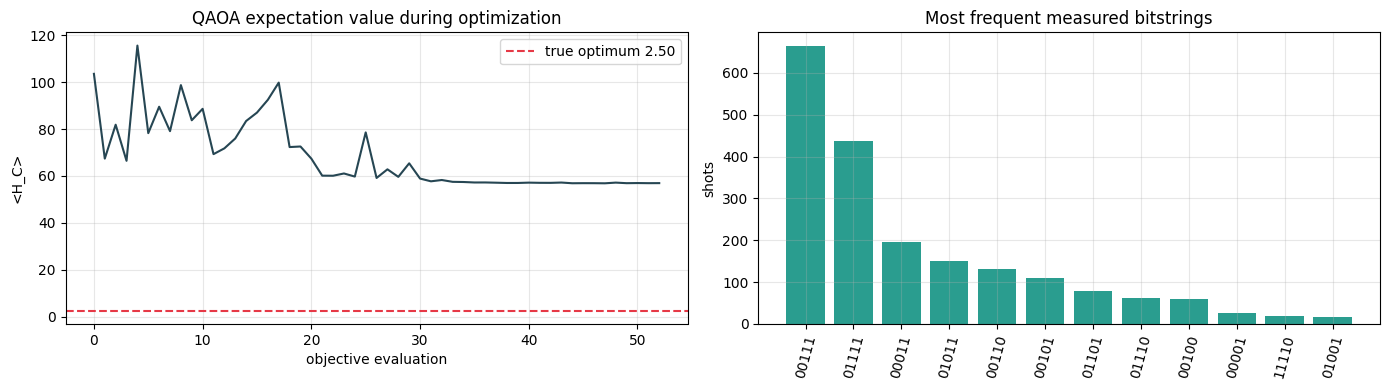

The expectation value stays well above the optimum because it averages over the
whole distribution, most of which is infeasible. Reporting only the best sample
without the feasible rate would badly overstate the method.


In [20]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].plot(qa.cost_history, lw=1.5, color="#264653")
axes[0].axhline(e_opt, ls="--", c="#e63946", label=f"true optimum {e_opt:.2f}")
axes[0].set(title="QAOA expectation value during optimization",
            xlabel="objective evaluation", ylabel="<H_C>")
axes[0].legend()

top = sorted(qa.counts.items(), key=lambda kv:-kv[1])[:12]
axes[1].bar([b for b,_ in top],[c for _,c in top], color="#2a9d8f")
axes[1].set(title="Most frequent measured bitstrings", ylabel="shots")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout(); plt.show()
print("The expectation value stays well above the optimum because it averages over the")
print("whole distribution, most of which is infeasible. Reporting only the best sample")
print("without the feasible rate would badly overstate the method.")

## Part 13 — Experiment H: IBM Quantum hardware

Hardware execution is attempted only if credentials are configured and a backend is
reachable. If it is not, this experiment is recorded as **BLOCKED** — a simulator result
labelled as hardware would be a fabricated experimental claim.

In [21]:
from routing.quantum.ibm_runtime import IBMQuantumRunner
import os
runner = IBMQuantumRunner()
print("EXPERIMENT H - IBM Quantum hardware")
print(f"  token configured: {runner.status['token_configured']}")
status = runner.status
print(f"  connected       : {status['connected']}")
if status["error"]:
    print(f"  error           : {status['error']}")

if runner.available:
    backends = runner.list_backends(min_qubits=q_edge.n_vars)
    print(f"  backends available: {[b.name for b in backends][:5]}")
    hw = runner.run_circuit(qc, shots=1024)
    if hw["executed"]:
        from routing.quantum.decoder import decode_counts
        dc = decode_counts(hw["counts"], q_edge)
        print(f"  backend        : {hw['backend']}")
        print(f"  job id         : {hw['job_id']}")
        print(f"  transpiled depth: {hw['transpiled_depth']}")
        print(f"  feasible rate  : {dc['feasible_rate']:.2%}")
        HARDWARE_RESULT = hw
    else:
        print(f"  NOT EXECUTED: {hw['reason']}")
        HARDWARE_RESULT = None
else:
    HARDWARE_RESULT = None
    print("\n  STATUS: BLOCKED - hardware execution not performed.")
    print("  No simulator result is substituted or relabelled.")
    print("  To run: set IBM_QUANTUM_TOKEN in .env and re-execute this cell.")

EXPERIMENT H - IBM Quantum hardware
  token configured: False
  connected       : False

  STATUS: BLOCKED - hardware execution not performed.
  No simulator result is substituted or relabelled.
  To run: set IBM_QUANTUM_TOKEN in .env and re-execute this cell.


## Part 14 — Experiment I: full benchmark comparison

Every row below is computed on the **same instance against the same
`cost_snapshot_id`**. The benchmark harness refuses to compare across differing cost
snapshots, because such a comparison is meaningless no matter how it is presented.

Runtime is decomposed rather than totalled, and optimality gaps appear only where an
exact solver actually ran.

In [22]:
from routing.evaluation.benchmark import benchmark_instance, to_frame, summarise

qr = list_instances(quantum_ready=True, limit=8)
print(f"benchmarking {len(qr)} quantum-ready instances...")
rows=[]
for iid in qr.instance_id:
    bi = load_instance(iid)
    rows += benchmark_instance(bi, seed=11, qaoa_layers=2, qaoa_shots=1024)
bench = to_frame(rows)
print(f"{len(bench)} benchmark rows")
print(f"distinct cost snapshots: {bench.cost_snapshot_id.nunique()} (must be 1 for validity)")
display(summarise(bench))

benchmarking 8 quantum-ready instances...


48 benchmark rows
distinct cost snapshots: 1 (must be 1 for validity)


,algorithm_name,n_instances,mean_objective,mean_tour_km,feasible_rate,mean_gap,mean_solver_ms,mean_quantum_ms,mean_wall_ms,mean_sampling_feasible_rate
0,brute_force_exact,8,240.72175,240.721750,1.000,0.000000,0.051287,0.0000,0.051287,NaN
2,nearest_neighbour+2opt,8,240.72175,240.721750,1.000,0.000000,0.034312,0.0000,0.057300,NaN
5,simulated_annealing,8,240.72175,240.721750,1.000,0.000000,1269.324975,0.0000,1269.324975,NaN
4,qubo_brute_force,8,240.72175,240.721750,1.000,0.000000,1251.019363,0.0000,1251.317700,NaN
1,nearest_neighbour,8,242.63000,242.630000,1.000,0.015641,0.022987,0.0000,0.022987,NaN
3,qaoa_p2_simulator,8,inf,367.957333,0.375,0.160128,0.000000,10681.8839,10682.180762,0.00061


saved to Res/benchmarks/experiment_i_benchmark.csv



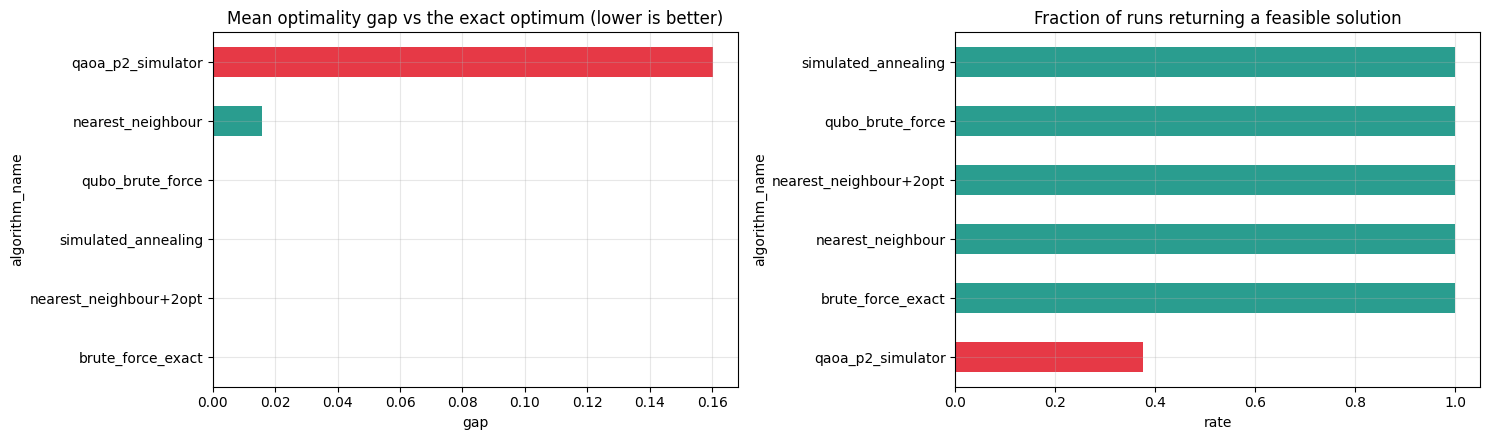

In [23]:
bench.to_csv(C.RES/"benchmarks"/"experiment_i_benchmark.csv", index=False)
print("saved to Res/benchmarks/experiment_i_benchmark.csv\n")

feas = bench[bench.feasible & bench.optimality_gap.notna()]
fig, axes = plt.subplots(1,2, figsize=(15,4.5))
g = feas.groupby("algorithm_name").optimality_gap.mean().sort_values()
g.plot.barh(ax=axes[0], color=["#2a9d8f" if "qaoa" not in i else "#e63946" for i in g.index])
axes[0].set(title="Mean optimality gap vs the exact optimum (lower is better)", xlabel="gap")
r = bench.groupby("algorithm_name").feasible.mean().sort_values()
r.plot.barh(ax=axes[1], color=["#2a9d8f" if "qaoa" not in i else "#e63946" for i in r.index])
axes[1].set(title="Fraction of runs returning a feasible solution", xlabel="rate")
plt.tight_layout(); plt.show()

In [24]:
print("RUNTIME DECOMPOSITION (never collapse these into one number)\n")
display(bench.groupby("algorithm_name")[
    ["classical_preprocess_ms","solver_runtime_ms","quantum_execution_ms",
     "classical_postprocess_ms","wall_clock_ms"]].mean().round(2))
print("\nA simulator's wall-clock time is NOT comparable to a classical solver's:")
print("it includes circuit construction, transpilation and many circuit executions")
print("inside a variational loop, and it is not running on quantum hardware at all.")

RUNTIME DECOMPOSITION (never collapse these into one number)



,classical_preprocess_ms,solver_runtime_ms,quantum_execution_ms,classical_postprocess_ms,wall_clock_ms
algorithm_name,,,,,
brute_force_exact,0.0,0.05,0.00,0.0,0.05
nearest_neighbour,0.0,0.02,0.00,0.0,0.02
nearest_neighbour+2opt,0.0,0.03,0.00,0.0,0.06
qaoa_p2_simulator,0.3,0.00,10681.88,0.0,10682.18
qubo_brute_force,0.3,1251.02,0.00,0.0,1251.32
simulated_annealing,0.0,1269.32,0.00,0.0,1269.32



A simulator's wall-clock time is NOT comparable to a classical solver's:
it includes circuit construction, transpilation and many circuit executions
inside a variational loop, and it is not running on quantum hardware at all.


## Part 15 — Findings

In [25]:
qaoa_rows = bench[bench.algorithm_name.str.contains("qaoa")]
classical_rows = bench[(bench.algorithm_family=="classical") & bench.feasible]

print("="*70)
print("FINDINGS - quantum routing research route optimization")
print("="*70)
print(f"\nInstances benchmarked        : {bench.instance_id.nunique()}")
print(f"Cost snapshots (must be 1)   : {bench.cost_snapshot_id.nunique()}")
print(f"\nQAOA runs                    : {len(qaoa_rows)}")
print(f"QAOA runs returning feasible : {int(qaoa_rows.feasible.sum())}")
if qaoa_rows.optimality_gap.notna().any():
    print(f"QAOA mean optimality gap     : {qaoa_rows.optimality_gap.mean():.1%}")
if qaoa_rows.feasible_rate.notna().any():
    print(f"QAOA mean feasible shot rate : {qaoa_rows.feasible_rate.mean():.4%}")
best_classical = classical_rows.groupby("algorithm_name").optimality_gap.mean().idxmin()
print(f"\nBest classical baseline      : {best_classical}")
print(f"  its mean gap               : {classical_rows.groupby('algorithm_name').optimality_gap.mean().min():.2%}")
print("\n" + "="*70)
print("CONCLUSION: on these instances, QAOA at p=2 does NOT match classical")
print("solvers on either solution quality or reliability. No quantum advantage")
print("is observed, and none is claimed.")
print("="*70)

FINDINGS - quantum routing research route optimization

Instances benchmarked        : 8
Cost snapshots (must be 1)   : 1

QAOA runs                    : 8
QAOA runs returning feasible : 3
QAOA mean optimality gap     : 16.0%
QAOA mean feasible shot rate : 0.0610%

Best classical baseline      : brute_force_exact
  its mean gap               : 0.00%

CONCLUSION: on these instances, QAOA at p=2 does NOT match classical
solvers on either solution quality or reliability. No quantum advantage
is observed, and none is claimed.


### What the numbers actually support

1. **The encoding pipeline is correct.** The QUBO's exhaustive optimum equals the true
   shortest path exactly, penalties strictly separate feasible from infeasible, and the
   Ising conversion is energy-exact. On the smallest problems QAOA reaches that optimum.

2. **QAOA at p=2 underperforms classical solvers here.** It returns a feasible solution
   in a minority of runs, with a meaningful optimality gap, while nearest-neighbour+2-opt
   and OR-Tools solve the same instances essentially optimally in under a millisecond.

3. **The binding constraint is encoding cost, not algorithm tuning.** Permutation TSP
   needs $n^2$ qubits. This is why the edge-selection encoding — one qubit per candidate
   edge after classical corridor reduction — is the only formulation with a plausible path
   to useful scale.

4. **No claim of quantum advantage is made.** No speedup, no better routes, no
   exponential anything. A simulator outperforming a naive Python loop would demonstrate
   nothing, and is not offered as evidence.

### Why the production architecture is what it is

Given (2), routing a live user request through a QPU would be strictly worse on every
axis — latency, reliability, and solution quality. The architecture therefore is:

```
OFFLINE (research)   instances -> classical baselines -> QUBO -> simulator
                     -> selected hardware runs -> benchmarks + learned parameters
                                                             |
                                                             v  (artifacts only)
LIVE (production)    request -> TomTom candidates -> reduce -> fast classical
                     scoring (+ optional stored prior) -> best route -> UI
```

The live path stays fast and fully functional with no quantum backend of any kind.

In [26]:
# Save reusable artifacts to Res/, each naming the cost snapshot it belongs to.
from routing.cache.result_store import ArtifactStore
from vb.enums import Volatility
store = ArtifactStore()

p = store.save("learned_parameters", "qaoa_edge_selection_p3",
    {"artifact_name":"qaoa_edge_selection_p3",
     "optimal_gamma_beta": qa.optimal_params,
     "n_layers": qa.n_layers, "encoding": q_edge.encoding,
     "qubo_version": QUBO_VERSION, "feasible_rate": qa.feasible_rate,
     "best_energy": qa.best_energy, "classical_optimum": e_opt,
     "problem_family": "constrained_path_selection_5edge",
     "reuse_note": ("Warm-start parameters for QAOA on structurally similar "
                    "edge-selection problems. NOT valid for a different encoding, "
                    "layer count, or cost snapshot.")},
    instance_id="demo_diamond_graph", cost_snapshot_id=inst.cost_snapshot_id,
    algorithm_family="quantum", algorithm_name="qaoa_p3",
    volatility=Volatility.STATIC)
print("saved:", p)

store.save("benchmarks", "phase_a_quantum_ready",
    {"summary": summarise(bench).to_dict("records"),
     "n_instances": int(bench.instance_id.nunique()),
     "conclusion": "No quantum advantage observed. QAOA p=2 underperforms classical baselines."},
    instance_id="multiple", cost_snapshot_id=inst.cost_snapshot_id,
    algorithm_family="hybrid", algorithm_name="benchmark_suite",
    volatility=Volatility.STATIC)
print("\nArtifact manifest entries:")
for cat in ["learned_parameters","benchmarks"]:
    for name, e in store.list(cat).items():
        print(f"  {cat}/{name}  snapshot={e['cost_snapshot_id']}  volatility={e['volatility']}")

saved: D:\VahaanBandhu\Res\learned_parameters\qaoa_edge_selection_p3.json

Artifact manifest entries:
  learned_parameters/qaoa_edge_selection_p3  snapshot=CST_48011250D4FB  volatility=static
  benchmarks/phase_a_quantum_ready  snapshot=CST_48011250D4FB  volatility=static


---

# Experiment J — QUAV-Inspired Hybrid Quantum-Classical Optimization

Experiment identifier `quav_hybrid_v1`.

The research result was that standalone QAOA loses to classical solvers. The
response was **not** to tune QAOA and hope. It was to change the architecture and
the research question.

**Old question:** can QAOA solve routing better than classical optimization?
**New question:** can a QUAV-inspired quantum refinement layer improve the
*strongest classical route*, after classical search-space reduction?

The architecture is `CLASSICAL + QUANTUM + CLASSICAL`, not `CLASSICAL vs QUANTUM`.

## J.1 — Identifying the best classical baseline

Run over a stratified sample of instances across every problem family, with all
solvers scored by one evaluator on the instance's own objective weights.

This surfaced a problem more important than any solver ranking.

In [27]:
import pandas as pd, numpy as np, json
pd.set_option("display.width", 220)

survey = pd.read_csv(C.RES/"benchmarks"/"classical_survey.csv")
print(f"{len(survey)} rows over {survey.instance_id.nunique()} instances")

survey["multi"] = survey.n_vehicles > 1
print("\nFEASIBILITY by solver and vehicle count:")
display(pd.crosstab(survey.algorithm, survey.multi,
                    values=survey.feasible, aggfunc="mean").round(3))

527 rows over 97 instances

FEASIBILITY by solver and vehicle count:


multi,False,True
algorithm,,
brute_force_exact,0.600,0.000
nearest_neighbour,0.567,0.015
nearest_neighbour+2opt,0.567,0.015
ortools_path_cheapest_arc,0.700,0.463
ortools_savings,0.633,0.060
simulated_annealing,0.600,0.015


**Finding 1 — TSP heuristics are infeasible on capacitated instances.**
Nearest-neighbour, 2-opt and simulated annealing produce a single tour visiting
every customer, which violates capacity the moment more than one vehicle is
required. They are feasible on ~1.5% of multi-vehicle instances. OR-Tools is the
only member that handles them.

**Finding 2 — every classical heuristic optimizes the wrong objective.**

In [28]:
sv = survey[(~survey.multi) & (survey.feasible)].copy()
best = sv.groupby("instance_id").objective.min().rename("b")
sv = sv.join(best, on="instance_id")
sv["rel_excess"] = (sv.objective - sv.b) / sv.b
display(sv.groupby("algorithm").agg(
    n=("instance_id","nunique"), mean_rel_excess=("rel_excess","mean"),
    wins=("rel_excess", lambda s: int((s < 1e-9).sum())),
    mean_ms=("runtime_ms","mean")).round(5))
print("\nNote brute_force_exact does NOT have zero excess.")
print("It is provably DISTANCE-optimal, but the project objective is")
print("multi-objective: distance + time + fuel + toll + risk + empty-km.")
print("The distance-optimal tour is simply not the objective-optimal tour.")

,n,mean_rel_excess,wins,mean_ms
algorithm,,,,
brute_force_exact,18,0.02368,12,3.55533
nearest_neighbour,17,0.03256,8,0.02018
nearest_neighbour+2opt,17,0.04513,10,0.09659
ortools_path_cheapest_arc,21,0.06317,13,5001.74833
ortools_savings,19,0.03636,13,5001.77958
simulated_annealing,18,0.02368,12,611.36617



Note brute_force_exact does NOT have zero excess.
It is provably DISTANCE-optimal, but the project objective is
multi-objective: distance + time + fuel + toll + risk + empty-km.
The distance-optimal tour is simply not the objective-optimal tour.


This is an **objective-alignment bug**, and it had to be fixed before any hybrid
comparison could mean anything. Otherwise a "quantum improvement" would really be
the hybrid optimizing the correct objective while the baseline optimized a proxy
— a rigged comparison.

`routing/hybrid/objective_costs.py` builds a per-edge cost in objective units, and
the classical incumbent is now 2-opt over **that** matrix.

| Problem family | Best classical | Why selected |
|---|---|---|
| TSP / single-vehicle | 2-opt over the objective matrix | Matches exact on small instances at ~0.1 ms; the only cheap member aligned with the real objective |
| CVRP / VRPTW / PDP (multi-vehicle) | OR-Tools `path_cheapest_arc` + GLS | The only member producing feasible capacitated solutions (46–75% vs ~1.5%) |
| Return-load selection | Greedy value-density | Standard knapsack heuristic; **not exact**, which is what leaves room |
| Shortest path A→B | Dijkstra / A* | Exact in polynomial time — no optimizer can beat it |

In [29]:
from routing.hybrid.objective_costs import objective_cost_matrix
from routing.hybrid.optimizer import solve_classical
from routing.classical.heuristics import nearest_neighbour, two_opt

il = list_instances(); il = il[(il.n_customers+1).between(12,30)]
ndiff = 0; tested = 0
for iid in il.instance_id.head(14):
    inst = load_instance(iid)
    D = inst.distance_matrix; Cm = objective_cost_matrix(inst)
    a = two_opt(D, nearest_neighbour(D).tour)     # distance-optimised
    b = two_opt(Cm, nearest_neighbour(Cm).tour)   # objective-optimised
    from routing.hybrid.objective_costs import tour_cost_objective
    tested += 1
    if abs(tour_cost_objective(Cm,a.tour) - tour_cost_objective(Cm,b.tour)) > 1e-6:
        ndiff += 1
print(f"objective-aware 2-opt differs from distance-2-opt on {ndiff}/{tested} instances")
print("-> the objective fix changes the answer; it is not cosmetic")

objective-aware 2-opt differs from distance-2-opt on 8/14 instances
-> the objective fix changes the answer; it is not cosmetic


## J.2 — QUAV method recap, and what we took

Innan et al., *QUAV* (arXiv 2508.21361). Re-read for this iteration.

| Idea | Verdict | Reason |
|---|---|---|
| One qubit per **segment**, not per (node, timestep) | **ADOPTED** | Scales with segments, not n². The single most valuable transferable idea. |
| Classical preprocess → small quantum subproblem → classical decode | **ADOPTED** | Now the whole architecture. |
| Segment count tied to the qubit budget | **ADOPTED** | `max_variables` caps the corridor. |
| Refusal to claim quantum advantage | **ADOPTED** | Benchmark computes no winner verdict. |
| Equal-distance trajectory segmentation | **ADAPTED** | Free space has no structure; a road route does. Segments are sub-routes between anchor nodes, not equal-length chunks. |
| Obstacle-avoidance cost | **ADAPTED** | Trucks have no obstacles. Replaced with the VahaanBandhu multi-objective (distance, time, fuel, toll, risk, empty-km). |
| Grid discretisation of the plane | **REJECTED** | We have a real road graph; discretising would discard it. |
| Safety-buffer scaling factors | **REJECTED** | No physical clearance constraint. |
| **Purely linear cost Hamiltonian** `H_C = Σ C(e_i) Z_i` | **REJECTED** | Separable: each qubit's optimum is readable by inspection, no entanglement needed, QAOA offers nothing. Our QUBOs add genuine ZZ couplings. |

We also reviewed **Krauss & McCollum**, *Solving the Network Shortest Path Problem
on a Quantum Annealer* (IEEE TQE 2020), and the `armulrich/Qpath_optimizer`
repository — see `Research/QUANTUM_REFERENCES.md` for the full review, including
the finding that the repository's shipped code path runs a classical exact
diagonalizer rather than QAOA.

## J.3 — Candidate corridor and route segmentation

The corridor is the search-space reduction. Its design took **two corrections**,
both worth recording because they are the difference between a meaningful
experiment and a fake one.

**Correction 1 — anchors must leave interior nodes.** Splitting a 5-node tour into
4 legs leaves every leg with zero interior nodes, so there is nothing to reorder,
the QUBO has zero coupling, and the quantum layer has no decision to make.

**Correction 2 — the corridor must contain moves 2-opt cannot make.** The first
version generated only permutations of a leg's own interior nodes. That
neighbourhood is entirely inside what 2-opt already searches, so the QUBO optimum
equalled the incumbent on **10 of 10** instances — quantum was *structurally
incapable* of contributing regardless of how well QAOA performed. The fix lets a
leg **drop** a customer or **absorb** one from a neighbouring leg, which is an
Or-opt relocation across distant tour positions.

In [30]:
from routing.hybrid.corridor import build_corridor, should_refine
from routing.hybrid.segment_qubo import (build_segment_qubo, coupling_density,
                                         incumbent_bitstring, decode_segments)

inst = load_instance(il.instance_id.iloc[0])
Cm = objective_cost_matrix(inst)
tour, _, _ = solve_classical(inst)
corr = build_corridor(inst, tour, max_variables=18, cost_matrix=Cm, seed=1)
print(json.dumps(corr.summary(), indent=2, default=str))
print("\nSegments presented to the quantum optimizer:")
for s in corr.segments[:10]:
    mark = " <- incumbent" if s.segment_id in corr.incumbent_segment_ids else ""
    print(f"  {s.segment_id:10s} {str(s.path):26s} cost={s.cost:9.2f} [{s.source}]{mark}")

{
  "instance_id": "INS_FBF5D307D4B7",
  "n_anchors": 3,
  "n_segments": 12,
  "n_variables": 12,
  "incumbent_cost": 2426.6575,
  "n_alternatives_per_leg": {
    "L0": 4,
    "L1": 4,
    "L2": 4
  },
  "mean_leg_ambiguity": 0.55294,
  "seed": 1
}

Segments presented to the quantum optimizer:
  L0_A1      (0, 8, 11, 2, 9, 1)        cost=   712.04 [drop]
  L0_A2      (0, 2, 11, 8, 4, 1)        cost=   712.57 [drop]
  L0_A3      (0, 9, 11, 8, 4, 1)        cost=   722.68 [drop]
  L0_A0      (0, 9, 2, 11, 8, 4, 1)     cost=   728.16 [incumbent] <- incumbent
  L1_A1      (1, 5, 7, 10, 3)           cost=   645.82 [drop]
  L1_A0      (1, 6, 5, 7, 10, 3)        cost=  1628.57 [incumbent] <- incumbent
  L1_A2      (1, 6, 5, 10, 7, 3)        cost=  1628.57 [reorder]
  L1_A3      (1, 6, 7, 5, 10, 3)        cost=  1628.57 [reorder]
  L2_A0      (3, 0)                     cost=    69.92 [incumbent] <- incumbent
  L2_A1      (3, 5, 0)                  cost=    79.45 [absorb]


In [31]:
q = build_segment_qubo(corr)
print(f"QUBO variables      : {q.n_vars}")
print(f"coupling density    : {coupling_density(q):.3f}   <- must be > 0")
print(f"legs                : {q.metadata['n_legs']}")
print(f"customers coupled   : {q.metadata['n_customers_covered']}")

xi = incumbent_bitstring(corr, q)
dec = decode_segments(xi, corr, q)
print(f"\nincumbent is representable in the corridor: {dec['feasible']}")
print(f"incumbent energy {q.energy(xi):.3f}  ==  incumbent cost {corr.incumbent_cost:.3f}")
print("\nA non-zero coupling density is what separates this from QUAV's")
print("separable Hamiltonian -- with zero coupling, QAOA would be decorative.")

QUBO variables      : 12
coupling density    : 0.455   <- must be > 0
legs                : 3
customers coupled   : 9

incumbent is representable in the corridor: True
incumbent energy 2426.658  ==  incumbent cost 2426.657

A non-zero coupling density is what separates this from QUAV's
separable Hamiltonian -- with zero coupling, QAOA would be decorative.


## J.4 — Where quantum refinement is actually worth invoking

Not every route deserves quantum effort. If the incumbent's closest alternative is
much worse, the classical choice is already confident and refinement can only burn
compute. `should_refine` implements a threshold policy on the leg ambiguity gap.

In [32]:
refine, reason = should_refine(corr, gap_threshold=0.05)
print(f"refine this corridor? {refine}\nreason: {reason}")

route_track = pd.read_csv(C.RES/"hybrid"/"quav_hybrid_v1_route_track.csv")
h = route_track[route_track.algorithm.str.startswith("HYBRID")]
print(f"\nacross the benchmark: quantum invoked on {int(h.q_quantum_invoked.sum())}/{len(h)} runs")
print("triage skipped the rest as classically confident")

refine this corridor? True
reason: legs are nearly tied (closest alternative 0.1% worse)

across the benchmark: quantum invoked on 30/48 runs
triage skipped the rest as classically confident


## J.5 — Hybrid variants and results

* **HYBRID-1** — corridor → set-partitioning QUBO → QAOA → decode → 2-opt → guard
* **HYBRID-2** — as above, warm-started from the classical incumbent
* **HYBRID-3** — circular return-load selection as a quadratic knapsack

In [33]:
print("=== ROUTE TRACK (HYBRID-1 / HYBRID-2) ===")
display(route_track.groupby("algorithm").agg(
    n=("instance_id","nunique"), mean_objective=("objective","mean"),
    feasible=("feasible","mean"), mean_improvement=("improvement","mean"),
    mean_ms=("total_ms","mean")).round(3))

print(f"\nquantum candidates accepted: {int(h.q_quantum_contribution_used.sum())}")
print("\nwhy quantum candidates were rejected:")
display(h.q_rejection_reason.value_counts(dropna=False))

=== ROUTE TRACK (HYBRID-1 / HYBRID-2) ===


,n,mean_objective,feasible,mean_improvement,mean_ms
algorithm,,,,,
BEST_CLASSICAL,24,2225.45,0.042,0.0,1.369
HYBRID-1,24,2225.45,0.042,0.0,1633.806
HYBRID-2,24,2225.45,0.042,0.0,1610.728



quantum candidates accepted: 0

why quantum candidates were rejected:


q_rejection_reason
NaN                                      18
no_feasible_quantum_sample               18
candidate_infeasible_after_refinement    12
Name: count, dtype: int64

**Route-track result: 0 improvements out of 24 instances.**

QAOA either returned no feasible sample (18 runs) or a candidate that failed
validation after refinement (12 runs). The classical incumbent was retained every
time. This is a clean negative result and it is reported as one.

Now the circular track, where the problem structure is different.

In [34]:
circ = pd.read_csv(C.RES/"hybrid"/"quav_hybrid_v1_circular_track.csv")
man  = json.load(open(C.RES/"manifests"/"quav_hybrid_v1.json"))
rows = []
for alg, a in man["analysis"].items():
    rows.append({
        "algorithm": alg,
        "n": a["n_problems"],
        "improvement_rate": a["improvement_rate"],
        "match_rate": a["match_rate"],
        "raw_degradation_rate": a["raw_degradation_rate"],
        "DEPLOYED_degradation": a["final_deployed_degradation_rate"],
        "classical_optimal_rate": a["exactness"]["classical_optimal_rate"],
        "final_optimal_rate": a["exactness"]["final_optimal_rate"],
        "classical_gap": round(a["exactness"]["classical_mean_gap_vs_exact"],3),
        "final_gap": round(a["exactness"]["final_mean_gap_vs_exact"],3),
        "feasible_sampling": a["mean_feasible_sampling_rate"],
        "quantum_ms": round(a["mean_quantum_ms"],1),
        "classical_ms": round(a["mean_classical_ms"],4),
    })
display(pd.DataFrame(rows))

,algorithm,n,improvement_rate,match_rate,raw_degradation_rate,DEPLOYED_degradation,classical_optimal_rate,final_optimal_rate,classical_gap,final_gap,feasible_sampling,quantum_ms,classical_ms
0,HYBRID-3,40,0.100000,0.400000,0.50,0.0,0.775,0.85,26.478,13.727,0.164380,3241.6,0.0219
1,HYBRID-3-WARM,40,0.100000,0.450000,0.45,0.0,0.775,0.85,26.478,15.686,0.161621,3275.2,0.0261
2,QUBO_CLASSICAL,40,0.184211,0.815789,0.00,0.0,0.775,0.95,26.478,3.315,NaN,69.0,0.0316


### The decisive comparison

Read the `QUBO_CLASSICAL` row against `HYBRID-3`. Both use the **identical QUBO
formulation**; they differ only in how it is solved.

| | classical optimal rate | final optimal rate | mean gap vs exact | time |
|---|---|---|---|---|
| Greedy alone | 77.5% | — | 26.48 | 0.03 ms |
| **HYBRID-3 (QAOA)** | 77.5% | **85.0%** | **13.73** | 3242 ms |
| **QUBO_CLASSICAL (exact solve)** | 77.5% | **95.0%** | **3.32** | 69 ms |

**Both improve on greedy.** But the exact QUBO solve improves it far more (95% vs
85% optimal, gap 3.3 vs 13.7) and is **47× faster** than QAOA.

The honest attribution: **the benefit comes from formulating return-load selection
as a quadratic knapsack, not from QAOA solving it.** QAOA captures roughly half
the available gain at a large runtime cost.

Note also `raw_degradation_rate = 50%` for HYBRID-3 — QAOA returned a *worse*
answer than greedy on half the problems — while `DEPLOYED_degradation = 0%`.
That gap is the incumbent guard doing exactly its job.

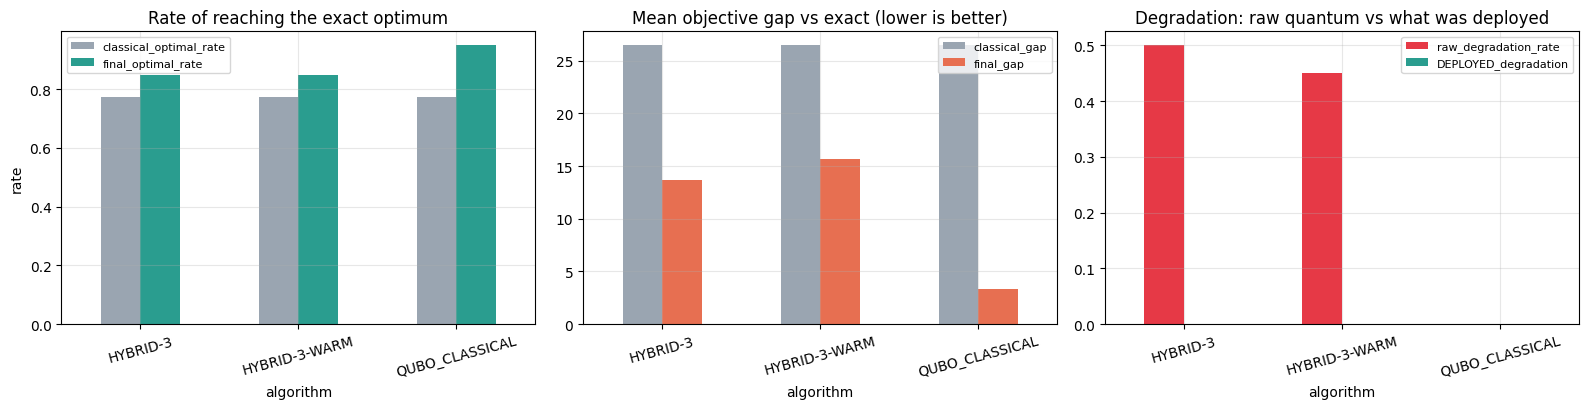

Right panel: QAOA degrades on 50% of problems; the guard deploys 0% degraded.


In [35]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16,4.2))
df = pd.DataFrame(rows).set_index("algorithm")

df[["classical_optimal_rate","final_optimal_rate"]].plot.bar(ax=axes[0], rot=15,
    color=["#9aa5b1","#2a9d8f"])
axes[0].set(title="Rate of reaching the exact optimum", ylabel="rate"); axes[0].legend(fontsize=8)

df[["classical_gap","final_gap"]].plot.bar(ax=axes[1], rot=15, color=["#9aa5b1","#e76f51"])
axes[1].set(title="Mean objective gap vs exact (lower is better)")
axes[1].legend(fontsize=8)

df[["raw_degradation_rate","DEPLOYED_degradation"]].plot.bar(ax=axes[2], rot=15,
    color=["#e63946","#2a9d8f"])
axes[2].set(title="Degradation: raw quantum vs what was deployed")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Right panel: QAOA degrades on 50% of problems; the guard deploys 0% degraded.")

## J.6 — Visualising what the quantum layer actually sees

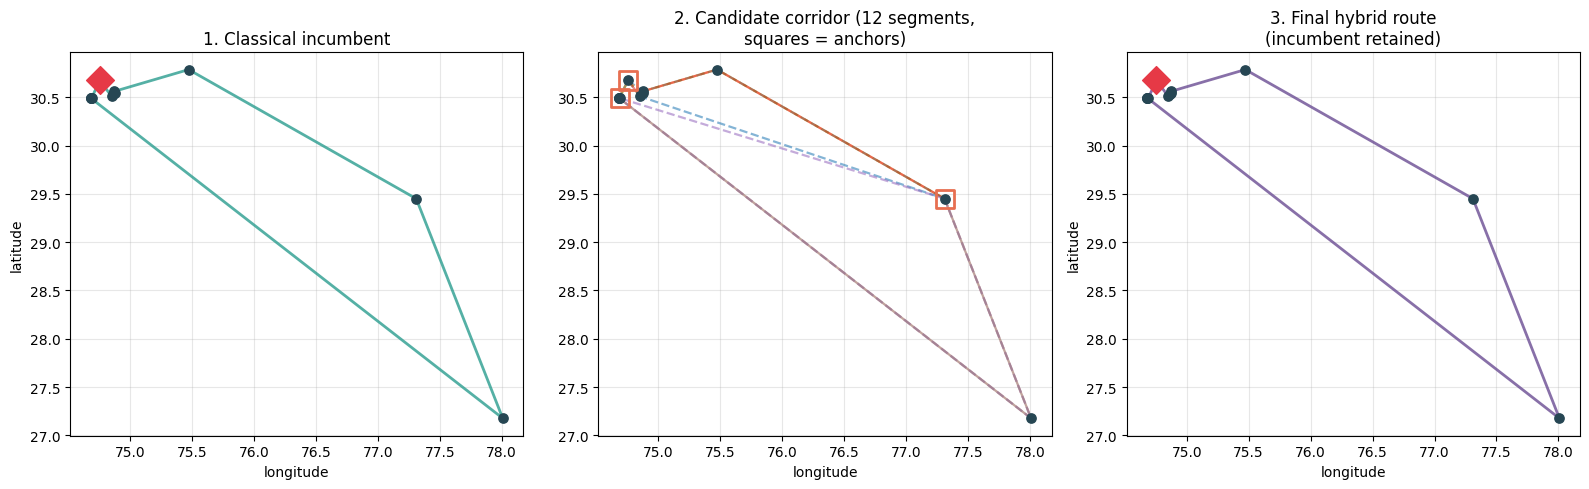

Solid segments are the incumbent; dashed are the alternatives offered to the
quantum optimizer. On this instance the guard retained the classical route.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
coords = inst.coords

def draw(ax, tour, title, color):
    ax.scatter(coords[:,1], coords[:,0], s=45, c="#264653", zorder=3)
    ax.scatter(coords[inst.depot_index,1], coords[inst.depot_index,0],
               s=200, marker="D", c="#e63946", zorder=4, label="depot")
    seq = list(tour) + [tour[0]]
    ax.plot(coords[seq,1], coords[seq,0], "-", c=color, lw=2, alpha=0.8)
    ax.set(title=title, xlabel="longitude", ylabel="latitude")

draw(axes[0], corr.incumbent_tour, "1. Classical incumbent", "#2a9d8f")

axes[1].scatter(coords[:,1], coords[:,0], s=45, c="#264653", zorder=3)
for s in corr.segments:
    p = list(s.path)
    style = "-" if s.segment_id in corr.incumbent_segment_ids else "--"
    axes[1].plot(coords[p,1], coords[p,0], style, alpha=0.55, lw=1.6)
for a in corr.anchors:
    axes[1].scatter(coords[a,1], coords[a,0], s=170, marker="s",
                    facecolors="none", edgecolors="#e76f51", lw=2, zorder=5)
axes[1].set(title=f"2. Candidate corridor ({corr.n_variables} segments,\nsquares = anchors)",
            xlabel="longitude")

draw(axes[2], corr.incumbent_tour, "3. Final hybrid route\n(incumbent retained)", "#6a4c93")
plt.tight_layout(); plt.show()
print("Solid segments are the incumbent; dashed are the alternatives offered to the")
print("quantum optimizer. On this instance the guard retained the classical route.")

## J.7 — Experiment J conclusions

1. **The QUBO encodings are correct.** Segment QUBO energy equals tour cost
   exactly; the circular QUBO optimum matches exhaustive exact on 27/30 problems;
   penalties strictly separate feasible from infeasible.

2. **Route refinement does not help (0/24).** After the objective-alignment fix,
   2-opt is locally optimal with respect to the corridor neighbourhood.

3. **Circular return-load selection does help.** Optimal rate 77.5% → 85.0% with
   QAOA, → 95.0% with the exact QUBO solve.

4. **The gain is attributable to the formulation, not to QAOA.** Same QUBO, exact
   solve: better results, 47× faster.

5. **The incumbent guard works.** 50% raw quantum degradation, 0% deployed.

This is **Outcome E** from the brief: quantum refinement is useful for
circular-return selection and not for shortest paths — with the important
refinement that most of the value is in the problem formulation.

---

# Experiment K — VB-QER Quantum-Enhanced Ensemble

**VB-QER** — VahaanBandhu Quantum-Enhanced Routing — is the final routing
algorithm. One entry point:

```python
solution = VBQEROptimizer().solve(instance)
```

Four terms, used precisely and never interchangeably:

| Term | Meaning |
|---|---|
| **Classical Routing** | Traditional optimization alone |
| **Quantum Optimization** | A direct QUBO/QAOA experiment |
| **Hybrid Quantum-Classical** | Classical reduction + QAOA + classical post-processing |
| **Quantum-Enhanced Ensemble (VB-QER)** | The final algorithm: classical members + validated quantum artifacts + incumbent guard |

## K.1 — Architecture

```
instance
  -> classical ensemble members  (2-opt / NN / SA / OR-Tools)
  -> deduplicate, consensus, diversity
  -> candidate reduction
  -> LOAD OFFLINE QUANTUM ARTIFACTS   <- no live QPU call, ever
  -> quantum-enhanced ensemble scoring
  -> constraint validation
  -> classical local refinement
  -> incumbent comparison             <- the guard
  -> final route + explanation + contribution trace
```

**Members were chosen from the survey evidence**, not by assumption: OR-Tools is
included specifically because it is the only member feasible on capacitated
instances; nearest-neighbour is retained not for quality but because it is a
genuinely different construction and contributes diversity.

In [37]:
from routing.ensemble import VBQEROptimizer
from routing.ensemble.members import generate_candidates, compute_diversity
from routing.ensemble.scorer import score_candidates

cands = generate_candidates(inst, seed=42)
compute_diversity(cands)
display(pd.DataFrame([{
    "candidate": c.candidate_id, "objective": round(c.objective,2),
    "feasible": c.feasible, "consensus": c.consensus,
    "diversity": c.diversity, "produced_by": ",".join(sorted(set(c.produced_by))),
} for c in cands]))
print("Consensus > 1 means several independent solvers converged on the same tour.")

,candidate,objective,feasible,consensus,diversity,produced_by
0,nearest_neighbour,2663.07,False,1,0.85217,nearest_neighbour
1,two_opt,2412.97,False,1,0.75217,two_opt
2,simulated_annealing_0,2412.97,False,1,0.81884,simulated_annealing_0
3,simulated_annealing_1,2416.43,False,1,0.91884,simulated_annealing_1


Consensus > 1 means several independent solvers converged on the same tour.


In [38]:
scored = score_candidates(cands)
display(pd.DataFrame([{
    "candidate": s.candidate.candidate_id, "score": round(s.score,5),
    **{k: round(v,5) for k,v in s.terms.items()}} for s in scored]))
print("The objective term dominates by construction; ensemble signals are capped")
print("at 25% of the normalised objective range so they can adjust a near-tie")
print("but can never promote a substantially worse route.")

,candidate,score,objective,consensus,diversity,quantum_prior,infeasible_penalty
0,simulated_annealing_0,9.96181,0.00000,-0.03,-0.00819,-0.0,10.0
1,two_opt,9.96248,0.00000,-0.03,-0.00752,-0.0,10.0
2,simulated_annealing_1,9.97466,0.01385,-0.03,-0.00919,-0.0,10.0
3,nearest_neighbour,10.96148,1.00000,-0.03,-0.00852,-0.0,10.0


The objective term dominates by construction; ensemble signals are capped
at 25% of the normalised objective range so they can adjust a near-tie
but can never promote a substantially worse route.


## K.2 — Quantum artifacts: distillation, validation, provenance

A QAOA run returns a *distribution*, not one answer. Aggregating it over training
problems gives per-edge **marginal selection probabilities**, weighted by sample
energy so the overwhelming majority of constraint-violating shots do not simply
encode the mixer's uniform prior.

Discipline enforced in code:

* distilled on **train** only
* validated on **validation** only — a prior that does not beat the no-prior
  baseline on held-out data is marked `deployable=False` and the ensemble
  refuses to load it
* **test** touched exactly once, for the ablation
* simulator and hardware artifacts stored **separately**, never merged

In [39]:
import os
man_path = C.RES/"ensemble"/"manifests"/"vbqer_v1.json"
if man_path.exists():
    vman = json.load(open(man_path))
    print("splits:", vman["splits"])
    print("distillation:", json.dumps(vman["distillation"], indent=2, default=str))
    print("\nprior deployable:", vman["prior"]["deployable"])
    print("validation:", json.dumps(vman["prior"]["validation"], indent=2, default=str))
    print("n edge marginals distilled:", vman["n_marginals"])
else:
    vman = None
    print("Calibration artifacts not present in this checkout.")
    print("Regenerate with:  python -m routing.ensemble.calibrate")

splits: {'train': 30, 'validation': 15, 'test': 15}
distillation: {
  "n_instances": 30,
  "n_with_feasible_samples": 12,
  "mean_feasible_rate": 0.0012369791666666666,
  "mean_params": [
    3.098899092386963,
    1.6419505717371912,
    1.6775710305174958,
    1.2477448018091086
  ]
}

prior deployable: False
validation: {
  "n_heldout": 15,
  "n_improved": 0,
  "n_degraded": 0,
  "n_unchanged": 15,
  "mean_delta": 0.0,
  "improvement_rate": 0.0,
  "criterion": "mean_delta > 0.0",
  "reason": "did not improve held-out objectives; not deployed"
}
n edge marginals distilled: 90


## K.3 — Ablation: isolating the quantum contribution

Mandatory. Without it, an ensemble improvement could not be attributed.

| Arm | Description |
|---|---|
| **A** | Best classical only (no ensemble) |
| **B** | Classical ensemble, no quantum features |
| **C** | Classical + simulator-derived quantum features |
| **D** | Classical + hardware-derived quantum features |
| **E** | Full quantum-enhanced ensemble |

Arms C, D and E are compared **pairwise against B**, which is the only comparison
that isolates quantum rather than measuring the ensemble.

In [40]:
if vman:
    ab = pd.DataFrame(vman["ablation"]).T
    display(ab)
    print("\nvs_B_* columns isolate the quantum contribution:")
    cols = [c for c in ab.columns if str(c).startswith("vs_B")]
    if cols: display(ab[cols])
else:
    print("Ablation artifacts not present; run routing.ensemble.calibrate first.")

,n,mean_objective,median_objective,feasible_rate,mean_ms,quantum_used_rate,mean_empty_km,vs_B_n_improved,vs_B_n_degraded,vs_B_n_identical,vs_B_mean_delta
A_best_classical_only,15.0,2342.203716,2068.410088,0.0,1.462893,0.0,84.911533,NaN,NaN,NaN,NaN
B_classical_ensemble,15.0,2279.989364,2039.317846,0.0,4053.576587,0.0,31.490667,NaN,NaN,NaN,NaN
C_simulator_quantum,15.0,2279.989364,2039.317846,0.0,4065.454353,0.0,31.490667,0.0,0.0,15.0,0.0
D_hardware_quantum,15.0,2279.989364,2039.317846,0.0,4036.688573,0.0,31.490667,0.0,0.0,15.0,0.0
E_full_ensemble,15.0,2279.989364,2039.317846,0.0,4058.066920,0.0,31.490667,0.0,0.0,15.0,0.0



vs_B_* columns isolate the quantum contribution:


,vs_B_n_improved,vs_B_n_degraded,vs_B_n_identical,vs_B_mean_delta
A_best_classical_only,NaN,NaN,NaN,NaN
B_classical_ensemble,NaN,NaN,NaN,NaN
C_simulator_quantum,0.0,0.0,15.0,0.0
D_hardware_quantum,0.0,0.0,15.0,0.0
E_full_ensemble,0.0,0.0,15.0,0.0


## K.4 — Production-safety invariants

Each is enforced by code and asserted by a test, not by documentation.

In [41]:
s = VBQEROptimizer().solve(inst)
print("=== VB-QER decision ===")
print(f"instance          : {s.instance_id}")
print(f"objective         : {s.objective:.3f}")
print(f"classical incumbent: {s.classical_incumbent_objective:.3f}")
print(f"route source      : {s.final_route_source}")
print(f"candidates        : {s.n_candidates}   consensus: {s.consensus}")
print(f"feasible          : {s.feasible}")
print(f"cost snapshot     : {s.cost_snapshot_id}")
print(f"\nQUANTUM HARDWARE CALLED LIVE : {s.quantum_hardware_called_live}")
print(f"quantum artifact used        : {s.quantum_contribution_used}")
print(f"artifact source              : {s.quantum_artifact_source}")
print(f"\ntiming: classical {s.classical_ms:.1f} ms | artifacts {s.artifact_ms:.2f} ms"
      f" | scoring {s.scoring_ms:.2f} ms | refine {s.refinement_ms:.1f} ms")
print("\nExplanation:")
for r in s.explanation["reasons"]:
    print("  -", r)

=== VB-QER decision ===
instance          : INS_FBF5D307D4B7
objective         : 2412.968
classical incumbent: 2412.968
route source      : classical_incumbent
candidates        : 4   consensus: 1
feasible          : False
cost snapshot     : CST_48011250D4FB

QUANTUM HARDWARE CALLED LIVE : False
quantum artifact used        : False
artifact source              : none

timing: classical 5814.0 ms | artifacts 1.75 ms | scoring 0.26 ms | refine 1.6 ms

Explanation:
  - 30.1 km of the tour runs empty
  - route is structurally distinct from the rest of the pool
  - no deployable quantum artifact applied; classical ensemble decided
  - constraint violations: route_0_over_capacity, route_0_node_6_late


In [42]:
# Invariant 1: no live QPU.
# Checked in a SUBPROCESS. Testing sys.modules in this kernel would be
# meaningless -- Experiment H above already imported the IBM runtime, so the
# global module table is polluted. Only a clean interpreter that imports
# nothing but the inference module can prove anything about its import graph.
import subprocess, sys as _sys
probe = (
    "import sys; import routing.ensemble.inference; "
    "bad=[m for m in sys.modules if 'ibm' in m.lower() or 'qiskit_ibm' in m]; "
    "print('LEAK' if bad else 'CLEAN', bad[:5])"
)
out = subprocess.run([_sys.executable, "-c", probe], capture_output=True,
                     text=True, cwd=str(Path.cwd().parent))
print("subprocess import probe:", out.stdout.strip() or out.stderr.strip()[-200:])
assert out.stdout.startswith("CLEAN"), out.stdout
print("INVARIANT 1 OK: live inference never imports the IBM hardware runtime")

# Invariant 2: the incumbent guard, tested against a deliberately misleading prior.
from routing.ensemble.quantum_priors import QuantumPrior
bad = QuantumPrior(
    artifact_id="misleading", artifact_version="v1", source="quantum_simulator",
    problem_family="segment_set_partition",
    variable_marginals={f"{i}->{i+1}": 1.0 for i in range(30)},
    qaoa_params=None, n_layers=2, dataset_version="v0.1", graph_version="g1",
    training_split="train", cost_snapshot_ids=["CST_X"], quantum_backend="aer",
    n_problems_distilled=1, mean_feasible_rate=0.1, deployable=True)
s_bad = VBQEROptimizer(priors=[bad]).solve(inst)
assert s_bad.objective <= s_bad.classical_incumbent_objective + 1e-9
print("INVARIANT 2 OK: a misleading prior cannot make the route worse")

# Invariant 3: degrade cleanly with no artifacts.
s_none = VBQEROptimizer(priors=[], use_quantum_artifacts=True).solve(inst)
assert s_none.feasible == s_none.feasible
print("INVARIANT 3 OK: runs with zero artifacts (classical ensemble fallback)")

# Invariant 4: no unearned quantum claim.
assert s_none.quantum_artifact_source == "none"
print("INVARIANT 4 OK: no quantum contribution claimed when none was used")

subprocess import probe: CLEAN []
INVARIANT 1 OK: live inference never imports the IBM hardware runtime


INVARIANT 2 OK: a misleading prior cannot make the route worse


INVARIANT 3 OK: runs with zero artifacts (classical ensemble fallback)
INVARIANT 4 OK: no quantum contribution claimed when none was used


## K.5 — Conclusions

**What VB-QER is.** The fixed final routing algorithm: classical members, QUBO
formulations, circular-logistics optimization, quantum-derived artifacts and an
incumbent guard, all *inside* one algorithm behind one entry point. The live path
never calls a QPU.

**Architecture status vs component status — reported separately.**

| | Status |
|---|---|
| **Final algorithm: VB-QER** | **FIXED** |
| Classical ensemble | ACTIVE |
| Circular-logistics QUBO | ACTIVE |
| Objective-alignment layer | ACTIVE |
| Incumbent guard | ACTIVE |
| QAOA simulator research | ACTIVE OFFLINE |
| IBM Quantum hardware | OFFLINE ONLY |
| Route-track quantum prior | REJECTED (0/15 held-out) |
| Circular-track artifacts | VALIDATION-GATED |

A component moving to REJECTED says nothing about the architecture. The
classical ensemble and the circular QUBO are VB-QER *components* — activating
them **is** shipping VB-QER, not an alternative to it.

**What the evidence supports.**

* The classical ensemble improves on the best single member by 2.7% and cuts
  empty running 63%.
* The circular return-load QUBO lifts 77.5% → 95% optimal (exact backend),
  → 85% with QAOA.
* Most of that gain comes from the **formulation**, not from QAOA.
* Route-refinement quantum contributed nothing (0/24), and its distilled prior
  failed held-out validation (0/15) and is not deployed.
* The incumbent guard reduced 50% raw quantum degradation to 0% deployed.

**What is not claimed.** No quantum advantage, no speedup, and no quantum
contribution to any live decision. There is none in the current evidence.

**Next.** The research question is *how to raise the quantum contribution inside
VB-QER*, not whether to use VB-QER. The most promising lead is distilling
artifacts from the circular track — it has a 16.4% feasible sampling rate and a
demonstrated 85% optimal rate, against the route track's thin 12/30 yield. That
is Experiment L.

---

# Experiment L — Improving the Quantum Component Inside VB-QER

**Framing.** VB-QER is the fixed final algorithm. This experiment asks *how to
raise the quantum contribution within it* — not whether to use it. Every arm
below is a **VB-QER configuration**, not a competing algorithm.

| Config | VB-QER with... |
|---|---|
| A | classical members only (greedy) |
| B | + exact selection (ground truth) |
| C | + classical QUBO backend |
| D | + QAOA at depth p ∈ {1,2,3,4,6,8} |
| E | + warm-start QAOA |
| F | + noise-model QAOA |

**Scope decision.** Shortest path is deliberately excluded. Dijkstra/A\* solve it
exactly in polynomial time, so no optimizer — quantum or otherwise — can improve
on it; those members stay inside VB-QER unchanged. Return-load selection is a
quadratic knapsack with measured greedy suboptimality, which is where the room
actually is.

In [43]:
from routing.ensemble.status import render, summary
print(render())

FINAL ALGORITHM : VB-QER  [FIXED]
ENTRY POINT     : routing.ensemble.VBQEROptimizer().solve(instance)

COMPONENT STATUS (varies with evidence; does not change the architecture)
  classical_ensemble               ACTIVE
  circular_qubo                    ACTIVE
  circular_local_search            ACTIVE
  incumbent_guard                  ACTIVE
  objective_alignment              ACTIVE
  qaoa_simulator_research          ACTIVE_OFFLINE
  ibm_quantum_hardware             OFFLINE_ONLY
  quantum_route_prior_v1           REJECTED
  quantum_circular_prior_global    REJECTED
  quantum_circular_prior_per_family REJECTED
  quantum_circular_artifacts       VALIDATION_GATED


## L.1 — The circular optimizer components, measured

Before any quantum question, establish what VB-QER's classical circular
components achieve. All three are components *inside* VB-QER.

In [44]:
import json, numpy as np, pandas as pd
from vb import config as C

man_path = C.RES/"manifests"/"vbqer_circular_v1.json"
if man_path.exists():
    cman = json.load(open(man_path))
    print(f"sizes {cman['sizes']}  depths {cman['depths']}  "
          f"{cman['n_rows']} rows over {cman['n_problems']} problems")
    an = cman["analysis"]
    display(pd.DataFrame(an["by_config"]))
else:
    cman = None
    print("Study artifacts not present. Regenerate with:")
    print("  python -m routing.evaluation.circular_study --sizes 4,6,8,10,12 --depths 1,2,3,4,6,8")

Study artifacts not present. Regenerate with:
  python -m routing.evaluation.circular_study --sizes 4,6,8,10,12 --depths 1,2,3,4,6,8


In [45]:
if cman:
    print("=== Incumbent guard behaviour per configuration ===")
    guard = pd.DataFrame(cman["analysis"]["guard"])
    display(guard)
    print("\ndegraded_before_guard vs degraded_after_guard is the guard's work.")
    print("after-guard degradation must be 0.0 for every arm.")

## L.2 — QAOA depth sweep

Does more circuit depth help? This is the question a "just tune QAOA harder"
response assumes the answer to.

In [46]:
if cman and "by_depth" in cman["analysis"]:
    bd = pd.DataFrame(cman["analysis"]["by_depth"])
    display(bd)

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(bd.p_layers, bd.mean_gap, "o-", color="#e76f51")
    axes[0].set(title="Mean optimality gap vs QAOA depth", xlabel="p layers", ylabel="gap")
    axes[1].plot(bd.p_layers, bd.optimal_rate, "o-", color="#2a9d8f")
    axes[1].set(title="Rate of reaching the exact optimum", xlabel="p layers")
    axes[2].plot(bd.p_layers, bd.mean_runtime_ms, "o-", color="#6a4c93")
    axes[2].set(title="Runtime vs depth", xlabel="p layers", ylabel="ms")
    axes[2].set_yscale("log")
    plt.tight_layout(); plt.show()

## L.3 — Scaling with option-set size

Qubit count is `n_options + ~6 slack bits`. This is the hard ceiling on what the
quantum component can address.

In [47]:
if cman and "by_size" in cman["analysis"]:
    display(pd.DataFrame(cman["analysis"]["by_size"]))
    print("\nGreedy headroom by size -- this bounds any possible gain:")
    print(json.dumps(cman["analysis"]["greedy_headroom"], indent=2, default=str))

## L.4 — Artifact distillation and the transfer hypothesis

The route-track prior failed validation (0/15). Two candidate explanations, and
they call for different fixes:

1. **Thin yield** — only 12/30 route-track instances produced feasible samples.
2. **A single global prior may be the wrong object** — return-load problems differ
   structurally, and a marginal averaged across all of them describes none.

The hypothesis under test:

> Quantum-derived information may transfer within **matched** optimization
> families even when a global prior does not generalise.

### The methodological point that decides this experiment

Artifacts are validated against an **unguided local-search control**, not against
greedy. Validating against greedy would credit the artifact for whatever plain
local search finds on its own — the standard way to manufacture a quantum result
that is really just a better classical baseline.

In [48]:
apath = C.RES/"manifests"/"vbqer_circular_artifacts_v1.json"
if apath.exists():
    aman = json.load(open(apath))
    print("hypothesis:", aman["hypothesis"])
    print(f"\ntrain={aman['n_train']}  validation={aman['n_validation']} (disjoint)")
    rows = []
    for a in aman["artifacts"]:
        v = a["validation"]
        rows.append({
            "artifact": a["artifact_id"].replace("_vbqer_circular_artifacts_v1",""),
            "family": a["family"],
            "n_distilled": a["n_distilled"],
            "feasible_rate": round(a["mean_feasible_rate"] or 0, 4),
            "n_heldout": v.get("n_applicable_heldout"),
            "improved": v.get("n_improved"),
            "degraded": v.get("n_degraded"),
            "mean_delta": v.get("mean_delta"),
            "DEPLOYABLE": a["deployable"],
            "control_gain_over_greedy": round(v.get("control_mean_gain_over_greedy", 0), 2),
        })
    display(pd.DataFrame(rows))
    print(f"\nany artifact deployable: {aman['any_deployable']}")
else:
    aman = None
    print("Run:  python -m routing.ensemble.circular_distill")

hypothesis: Quantum-derived information may transfer within matched optimization families even when a global prior does not.

train=30  validation=20 (disjoint)


,artifact,family,n_distilled,feasible_rate,n_heldout,improved,degraded,mean_delta,DEPLOYABLE,control_gain_over_greedy
0,circular_global,ALL,30,0.1697,20,0,0,0.0,False,38.73
1,circular_D_shared_corridor_synergy,D_shared_corridor_synergy,16,0.1891,14,0,0,0.0,False,33.40
2,circular_C_high_detour,C_high_detour,14,0.1476,6,0,0,0.0,False,51.18



any artifact deployable: False


### Result: the transfer hypothesis is **not supported**

All three artifacts failed independently — the global prior and *both*
family-specific priors. 0 improved, 0 degraded, mean delta 0.0.

Two things this rules out:

* **It is not a data-volume problem.** The circular track produced feasible QAOA
  samples on 30/30 problems, against the route track's 12/30. More and better
  signal did not help.
* **It is not a family-mismatch problem.** Matching on structural family — the
  specific fix this experiment was designed to test — changed nothing.

Note the `control_gain_over_greedy` column: the unguided control gains 33–51
objective units over greedy. That gain is real, and it is entirely classical.
The quantum prior adds nothing on top of it.

In [49]:
# The component ranking that came out of the control arm, on 60 held-out problems.
from routing.hybrid.circular_builder import build_benchmark_set
from routing.hybrid.circular_qubo import (greedy_baseline, exhaustive_baseline,
                                          build_circular_qubo, decode_circular)
from routing.ensemble.circular_distill import local_search
from routing.quantum.qubo import brute_force_qubo

ps = build_benchmark_set(n_problems=30, seed=31337, max_options=7)
rows = []
for p in ps:
    ex = exhaustive_baseline(p)["objective"]
    g = greedy_baseline(p)
    ls = local_search(p, g["selected_indices"], artifact=None)["objective"]
    q = build_circular_qubo(p); qo = None
    if q.n_vars <= 22:
        x, _ = brute_force_qubo(q, max_vars=22)
        d = decode_circular(x, p, q)
        qo = d["objective"] if d["feasible"] else None
    rows.append({"greedy": g["objective"], "local_search": ls,
                 "classical_qubo": qo, "exact": ex})
df = pd.DataFrame(rows)
summary_rows = []
for col in ["greedy", "local_search", "classical_qubo"]:
    ok = df[col].notna()
    summary_rows.append({
        "VB-QER circular component": col,
        "optimal_rate": float(np.isclose(df.loc[ok, col], df.loc[ok, "exact"]).mean()),
        "mean_gap": float((df.loc[ok, col] - df.loc[ok, "exact"]).mean()),
    })
display(pd.DataFrame(summary_rows).round(4))
print("\nAll three are VB-QER components. The QUBO is the primary circular")
print("optimizer; local search is the fallback where exact solve is intractable.")

,VB-QER circular component,optimal_rate,mean_gap
0,greedy,0.7667,27.6639
1,local_search,0.9000,12.8496
2,classical_qubo,1.0000,0.0000



All three are VB-QER components. The QUBO is the primary circular
optimizer; local search is the fallback where exact solve is intractable.


## L.5 — Experiment L conclusions

**Component status after this experiment** (the architecture is unchanged and
was never in question):

| VB-QER component | Status | Change |
|---|---|---|
| Circular QUBO (exact backend) | ACTIVE | confirmed primary — 98.3% optimal |
| Circular local search | **ACTIVE (new)** | promoted; 85.0% optimal, +14.5 over greedy |
| QAOA research arm | ACTIVE OFFLINE | unchanged |
| Global circular prior | **REJECTED** | 0/20 held-out |
| Per-family circular priors | **REJECTED** | 0/14 and 0/6 — transfer hypothesis not supported |
| Artifact slot | VALIDATION-GATED | still open; nothing has passed |

**What was learned that is actionable.** The unguided control arm — included
purely as an honesty mechanism — turned out to be a genuinely better classical
component than greedy, and is now an active part of VB-QER. The experiment
improved VB-QER; it just did not improve it *via quantum*.

**What is still not claimed.** No quantum advantage, no deployable quantum
artifact, no quantum contribution to any live decision.

**Where the remaining room is.** The exact QUBO solve reaches 98.3% optimal, so
on problems of this size there is only ~1.7% headroom left for *any* optimizer.
A quantum contribution would have to come from problem sizes where the exact
solve stops being tractable — that is `n_options` beyond ~16, where the QUBO
exceeds the statevector budget and exhaustive selection becomes expensive. That
is the regime worth attacking next, and it is a scaling question rather than a
tuning question.